In [1]:
#data handling libs
import numpy as np
import pandas as pd


#sklearn libs
from sklearn.model_selection import train_test_split

#data viz
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

#importing custom-made functions
import sys #importing local functions in src folder
sys.path.append('../src/')
from utils import *

In [2]:
output = "../data/raw/loan_data_2007_2014.csv"

In [3]:
loan_data = pd.read_csv(output)

/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/1931725289.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  loan_data = pd.read_csv(output)


In [4]:
loan_data.shape

(466285, 75)

In [5]:
loan_data.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
loan_data.tail()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
466280,466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,C,...,NaN,NaN,NaN,NaN,NaN,NaN,29900.0,NaN,NaN,NaN
466281,466281,9684700,11536848,22000,22000,22000.0,60 months,19.97,582.50,D,...,NaN,NaN,NaN,NaN,NaN,NaN,39400.0,NaN,NaN,NaN
466282,466282,9584776,11436914,20700,20700,20700.0,60 months,16.99,514.34,D,...,NaN,NaN,NaN,NaN,NaN,NaN,13100.0,NaN,NaN,NaN
466283,466283,9604874,11457002,2000,2000,2000.0,36 months,7.90,62.59,A,...,NaN,NaN,NaN,NaN,NaN,NaN,53100.0,NaN,NaN,NaN
466284,466284,9199665,11061576,10000,10000,9975.0,36 months,19.20,367.58,D,...,NaN,NaN,NaN,NaN,NaN,NaN,16000.0,NaN,NaN,NaN


In [7]:
loan_data.columns.values

array(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
       'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'veri

In [8]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [9]:
### General Preprocessing ###
pd.get_dummies(loan_data['grade'], prefix = 'grade', prefix_sep = ':').head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G
0,False,True,False,False,False,False,False
1,False,False,True,False,False,False,False
2,False,False,True,False,False,False,False
3,False,False,True,False,False,False,False
4,False,True,False,False,False,False,False


In [11]:
dummy_columns = ['grade','sub_grade','home_ownership','verification_status',
                 'loan_status','purpose','addr_state','initial_list_status']

df_Dummies = pd.DataFrame()
for col in dummy_columns:
    df_Dummy = pd.get_dummies(loan_data[col], prefix=col, prefix_sep=':')
    df_Dummies = pd.concat([df_Dummies, df_Dummy], axis=1)

# Step 2 — attach to main dataframe (separate cell)
loan_data = pd.concat([loan_data, df_Dummies], axis=1)

In [12]:
df_Dummies.columns.values

array(['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F',
       'grade:G', 'sub_grade:A1', 'sub_grade:A2', 'sub_grade:A3',
       'sub_grade:A4', 'sub_grade:A5', 'sub_grade:B1', 'sub_grade:B2',
       'sub_grade:B3', 'sub_grade:B4', 'sub_grade:B5', 'sub_grade:C1',
       'sub_grade:C2', 'sub_grade:C3', 'sub_grade:C4', 'sub_grade:C5',
       'sub_grade:D1', 'sub_grade:D2', 'sub_grade:D3', 'sub_grade:D4',
       'sub_grade:D5', 'sub_grade:E1', 'sub_grade:E2', 'sub_grade:E3',
       'sub_grade:E4', 'sub_grade:E5', 'sub_grade:F1', 'sub_grade:F2',
       'sub_grade:F3', 'sub_grade:F4', 'sub_grade:F5', 'sub_grade:G1',
       'sub_grade:G2', 'sub_grade:G3', 'sub_grade:G4', 'sub_grade:G5',
       'home_ownership:ANY', 'home_ownership:MORTGAGE',
       'home_ownership:NONE', 'home_ownership:OTHER',
       'home_ownership:OWN', 'home_ownership:RENT',
       'verification_status:Not Verified',
       'verification_status:Source Verified',
       'verification_status:Verified', 'lo

###  Continuous variables - Dt format conversion

In [13]:
loan_data['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [14]:
loan_data['emp_length_int'] = loan_data['emp_length'].str.replace('+ years', '', regex=False)
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace('< 1 year', '0', regex=False)
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace('n/a', '0', regex=False)
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace(' years', '', regex=False)
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace(' year', '', regex=False)
loan_data['emp_length_int'] = pd.to_numeric(loan_data['emp_length_int'], errors='coerce').fillna(0).astype(int)

In [15]:
# date variables not in dt format
loan_data['earliest_cr_line']

0         Jan-85
1         Apr-99
2         Nov-01
3         Feb-96
4         Jan-96
           ...  
466280    Apr-03
466281    Jun-97
466282    Dec-01
466283    Feb-03
466284    Feb-00
Name: earliest_cr_line, Length: 466285, dtype: object

In [17]:
# Convert date column: 'Apr-03' → datetime
loan_data['earliest_cr_line_date'] = pd.to_datetime(loan_data['earliest_cr_line'], format='%b-%y')

# Months since reference date 2017-12-01
diff_cr_line = pd.to_datetime('2017-12-01') - loan_data['earliest_cr_line_date']
loan_data['mths_since_earliest_cr_line'] = (diff_cr_line.dt.days / 30.4375).round().fillna(0).astype(int)

In [18]:
loan_data['mths_since_earliest_cr_line'].describe()

count    466285.000000
mean        239.467536
std          93.990882
min        -612.000000
25%         183.000000
50%         225.000000
75%         285.000000
max         587.000000
Name: mths_since_earliest_cr_line, dtype: float64

In [19]:
m1 = loan_data['mths_since_earliest_cr_line']<0
loan_data.loc[m1,['earliest_cr_line','earliest_cr_line_date','mths_since_earliest_cr_line']].head()

,earliest_cr_line,earliest_cr_line_date,mths_since_earliest_cr_line
1580,Sep-62,2062-09-01,-537
1770,Sep-68,2068-09-01,-609
2799,Sep-64,2064-09-01,-561
3282,Sep-67,2067-09-01,-597
3359,Feb-65,2065-02-01,-566


In [20]:
loan_data.loc[m1,'mths_since_earliest_cr_line'] = loan_data.loc[:,'mths_since_earliest_cr_line'].max()

In [21]:
loan_data['term']

0          36 months
1          60 months
2          36 months
3          36 months
4          60 months
             ...    
466280     60 months
466281     60 months
466282     60 months
466283     36 months
466284     36 months
Name: term, Length: 466285, dtype: object

In [22]:
loan_data['term_int'] = loan_data['term'].str.replace(' months', '').astype(int)
loan_data['term_int'].describe()

count    466285.000000
mean         42.605334
std          10.719040
min          36.000000
25%          36.000000
50%          36.000000
75%          60.000000
max          60.000000
Name: term_int, dtype: float64

In [23]:
# Assuming we are in December 2017
loan_data['issue_d_date'] = pd.to_datetime(loan_data['issue_d'], format='%b-%y')

# Months since reference date 2017-12-01
diff_issue_d = pd.to_datetime('2017-12-01') - loan_data['issue_d_date']
loan_data['mths_since_issue_d'] = (diff_issue_d.dt.days / 30.4375).round().fillna(0).astype(int)

loan_data['mths_since_issue_d'].describe()

count    466285.000000
mean         51.255187
std          14.340154
min          36.000000
25%          41.000000
50%          47.000000
75%          57.000000
max         126.000000
Name: mths_since_issue_d, dtype: float64

### Checking for missing values or cleaning them 

In [24]:
loan_data.isnull().sum().sort_values(ascending=False)

open_il_6m                   466285
all_util                     466285
annual_inc_joint             466285
dti_joint                    466285
verification_status_joint    466285
                              ...  
sub_grade:D1                      0
sub_grade:D2                      0
sub_grade:D3                      0
sub_grade:D4                      0
mths_since_issue_d                0
Length: 207, dtype: int64

In [25]:
# Fill missing values
loan_data['total_rev_hi_lim'] = loan_data['total_rev_hi_lim'].fillna(loan_data['funded_amnt'])
loan_data['annual_inc'] = loan_data['annual_inc'].fillna(loan_data['annual_inc'].mean())

# Fill remaining columns with 0
cols_fill_zero = [
    'mths_since_earliest_cr_line', 'acc_now_delinq', 'total_acc',
    'pub_rec', 'open_acc', 'inq_last_6mths', 'delinq_2yrs', 'emp_length_int'
]
loan_data[cols_fill_zero] = loan_data[cols_fill_zero].fillna(0)

### PD Model Definition 

In [27]:
loan_data['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [28]:
loan_data['loan_status'].value_counts() / loan_data['loan_status'].count()

loan_status
Current                                                0.480878
Fully Paid                                             0.396193
Charged Off                                            0.091092
Late (31-120 days)                                     0.014798
In Grace Period                                        0.006747
Does not meet the credit policy. Status:Fully Paid     0.004263
Late (16-30 days)                                      0.002612
Default                                                0.001784
Does not meet the credit policy. Status:Charged Off    0.001632
Name: count, dtype: float64

In [ ]:
bad_def = ['Charged Off', 'Default','Does not meet the credit policy. Status: Charged Off.',
           'Late (31-120 days)']

#good is 1, bad is 0
loan_data['good_bad'] = np.where(loan_data['loan_status'].isin(bad_def), 0, 1)

In [30]:
loan_data['good_bad'].head()

0    1
1    0
2    1
3    1
4    1
Name: good_bad, dtype: int64

In [31]:
loan_data['good_bad'].value_counts() / loan_data['good_bad'].count()

good_bad
1    0.892326
0    0.107674
Name: count, dtype: float64

### Train Test Set Split

In [ ]:
inputs_train, inputs_test, targets_train, targets_test = train_test_split(
    loan_data.drop('good_bad',axis = 1), loan_data['good_bad'], test_size=0.2,
    random_state= 75)

In [33]:
inputs_train.shape

(373028, 207)

In [34]:
inputs_test.shape

(93257, 207)

### Selecting test or train set for preproc

In [113]:
# Process train set for WoE analysis (standard — avoids data leakage)
df_inputs_prepr = inputs_train
df_targets_prepr = targets_train
# To process test set instead, swap the two lines above with:
# df_inputs_prepr = inputs_test
# df_targets_prepr = targets_test

### Discrete Data Preparation - WoE

In [114]:
df_temp = woe_discrete(df_inputs_prepr, 'grade', df_targets_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,665,0.714286,0.007131,475.0,190.0,0.005715,0.018728,-1.186917,NaN,NaN,0.2879
1,F,2793,0.769782,0.029949,2150.0,643.0,0.025869,0.063381,-0.896130,0.055496,0.290788,0.2879
2,E,7067,0.808547,0.075780,5714.0,1353.0,0.068751,0.133366,-0.662613,0.038765,0.233517,0.2879
3,D,15429,0.846847,0.165446,13066.0,2363.0,0.157210,0.232923,-0.393127,0.038300,0.269486,0.2879
4,C,25131,0.886157,0.269481,22270.0,2861.0,0.267952,0.282011,-0.051139,0.039310,0.341988,0.2879
5,B,27201,0.919929,0.291678,25023.0,2178.0,0.301076,0.214687,0.338180,0.033773,0.389319,0.2879
6,A,14971,0.962795,0.160535,14414.0,557.0,0.173429,0.054904,1.150182,0.042865,0.812002,0.2879


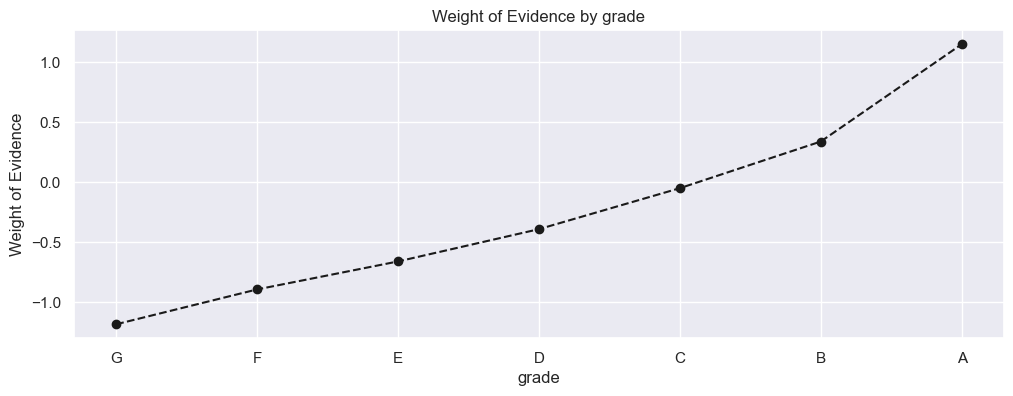

In [115]:
plot_by_woe(df_temp)

In [116]:
df_temp = woe_discrete(df_inputs_prepr, 'home_ownership',df_targets_prepr)
df_temp

,home_ownership,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,OTHER,52,0.846154,0.000558,44.0,8.0,0.000529,7.885658e-04,-0.398460,NaN,NaN,0.026403
1,RENT,37593,0.873035,0.403112,32820.0,4773.0,0.394889,4.704781e-01,-0.175145,0.026881,0.223315,0.026403
2,OWN,8276,0.890527,0.088744,7370.0,906.0,0.088676,8.930508e-02,-0.007074,0.017492,0.168071,0.026403
3,MORTGAGE,47330,0.905810,0.507522,42872.0,4458.0,0.515834,4.394283e-01,0.160311,0.015283,0.167385,0.026403
4,NONE,6,1.000000,0.000064,6.0,0.0,0.000072,1.000000e-09,11.187081,0.094190,11.026770,0.026403


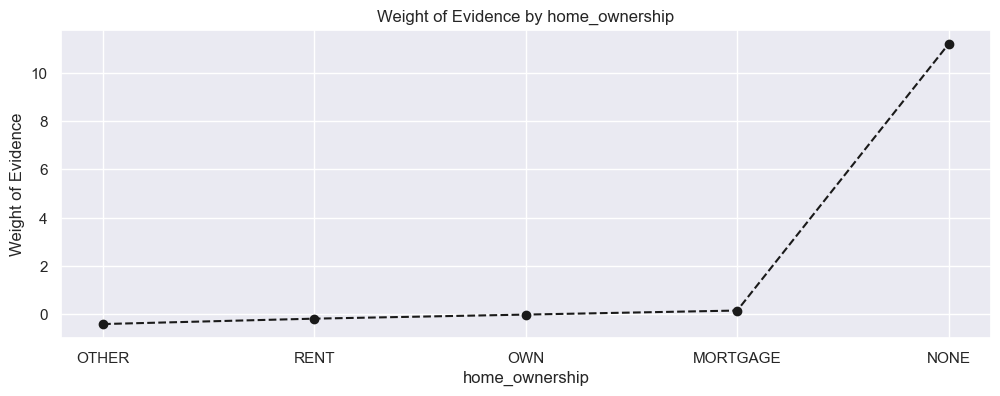

In [117]:
plot_by_woe(df_temp, 0)

In [118]:
df_inputs_prepr['home_ownership:RENT_OTHER_NONE_ANY'] = _safe_sum(df_inputs_prepr, [
    'home_ownership:RENT', 'home_ownership:OTHER',
    'home_ownership:NONE', 'home_ownership:ANY'
])

In [119]:
df_inputs_prepr['addr_state'].unique()

array(['NY', 'MD', 'GA', 'MO', 'MA', 'CA', 'FL', 'TX', 'WA', 'NC', 'LA',
       'OH', 'AL', 'NJ', 'SC', 'WI', 'VA', 'IL', 'AZ', 'PA', 'MI', 'TN',
       'NV', 'AR', 'DC', 'IN', 'KS', 'CO', 'MN', 'MS', 'WY', 'CT', 'HI',
       'UT', 'OK', 'KY', 'NM', 'OR', 'NH', 'VT', 'SD', 'WV', 'ID', 'AK',
       'RI', 'DE', 'MT', 'IA', 'NE', 'ME'], dtype=object)

In [120]:
df_temp = woe_discrete(df_inputs_prepr,'addr_state', df_targets_prepr)
df_temp

,addr_state,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,NV,1345,0.852045,0.014423,1146.0,199.0,0.013789,1.961557e-02,-0.352480,NaN,NaN,0.019562
1,DE,246,0.853659,0.002638,210.0,36.0,0.002527,3.548546e-03,-0.339620,0.001614,0.012861,0.019562
2,RI,429,0.867133,0.004600,372.0,57.0,0.004476,5.618531e-03,-0.227366,0.013474,0.112254,0.019562
3,FL,6348,0.869093,0.068070,5517.0,831.0,0.066380,8.191227e-02,-0.210248,0.001960,0.017117,0.019562
4,AL,1185,0.871730,0.012707,1033.0,152.0,0.012429,1.498275e-02,-0.186866,0.002637,0.023382,0.019562
5,OK,795,0.875472,0.008525,696.0,99.0,0.008374,9.758502e-03,-0.152978,0.003742,0.033888,0.019562
6,NC,2526,0.878464,0.027086,2219.0,307.0,0.026699,3.026121e-02,-0.125244,0.002992,0.027734,0.019562
7,NM,509,0.880157,0.005458,448.0,61.0,0.005390,6.012814e-03,-0.109289,0.001693,0.015955,0.019562
8,KY,947,0.881732,0.010155,835.0,112.0,0.010047,1.103992e-02,-0.094275,0.001575,0.015013,0.019562
9,VA,2807,0.882081,0.030100,2476.0,331.0,0.029791,3.262691e-02,-0.090927,0.000349,0.003348,0.019562


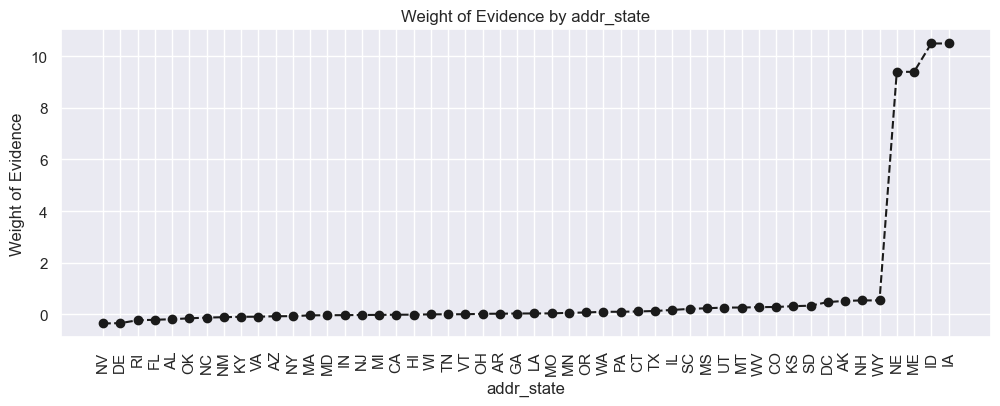

In [121]:
plot_by_woe(df_temp, 90)

In [122]:
if 'addr_state:ND' not in df_inputs_prepr.columns:
    df_inputs_prepr['addr_state:ND'] = 0

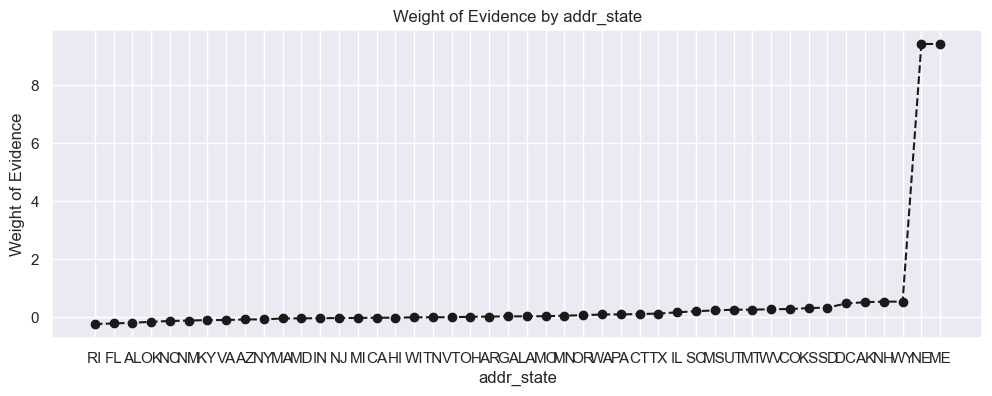

In [123]:
plot_by_woe(df_temp.iloc[2:-2,:])

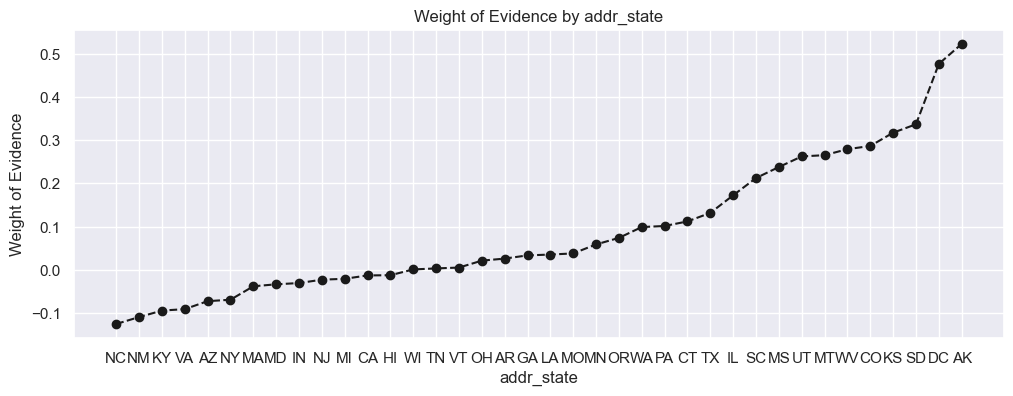

In [124]:
plot_by_woe(df_temp.iloc[6:-6,:])

In [125]:
# 'ND' 'NE' 'IA' NV' 'FL' 'HI' 'AL'
# 'NM' 'VA'
# 'NY'
# 'OK' 'TN' 'MO' 'LA' 'MD' 'NC'
# 'CA'
# 'UT' 'KY' 'AZ' 'NJ'
# 'AR' 'MI' 'PA' 'OH' 'MN'
# 'RI' 'MA' 'DE' 'SD' 'IN'
# 'GA' 'WA' 'OR'
# 'WI' 'MT'
# 'TX'
# 'IL' 'CT'
# 'KS' 'SC' 'CO' 'VT' 'AK' 'MS'
# 'WV' 'NH' 'WY' 'DC' 'ME' 'ID'

# 'IA_NV_HI_ID_AL_FL' will be the reference category.
# Using _safe_sum to avoid KeyError when rare states are absent from train/test split.
if 'addr_state:ND' not in df_inputs_prepr.columns:
    df_inputs_prepr['addr_state:ND'] = 0

df_inputs_prepr['addr_state:ND_NE_IA_NV_FL_HI_AL'] = _safe_sum(df_inputs_prepr, [
    'addr_state:ND', 'addr_state:NE', 'addr_state:IA', 'addr_state:NV',
    'addr_state:FL', 'addr_state:HI', 'addr_state:AL'])

df_inputs_prepr['addr_state:NM_VA'] = _safe_sum(df_inputs_prepr, [
    'addr_state:NM', 'addr_state:VA'])

df_inputs_prepr['addr_state:OK_TN_MO_LA_MD_NC'] = _safe_sum(df_inputs_prepr, [
    'addr_state:OK', 'addr_state:TN', 'addr_state:MO', 'addr_state:LA',
    'addr_state:MD', 'addr_state:NC'])

df_inputs_prepr['addr_state:UT_KY_AZ_NJ'] = _safe_sum(df_inputs_prepr, [
    'addr_state:UT', 'addr_state:KY', 'addr_state:AZ', 'addr_state:NJ'])

df_inputs_prepr['addr_state:AR_MI_PA_OH_MN'] = _safe_sum(df_inputs_prepr, [
    'addr_state:AR', 'addr_state:MI', 'addr_state:PA', 'addr_state:OH', 'addr_state:MN'])

df_inputs_prepr['addr_state:RI_MA_DE_SD_IN'] = _safe_sum(df_inputs_prepr, [
    'addr_state:RI', 'addr_state:MA', 'addr_state:DE', 'addr_state:SD', 'addr_state:IN'])

df_inputs_prepr['addr_state:GA_WA_OR'] = _safe_sum(df_inputs_prepr, [
    'addr_state:GA', 'addr_state:WA', 'addr_state:OR'])

df_inputs_prepr['addr_state:WI_MT'] = _safe_sum(df_inputs_prepr, [
    'addr_state:WI', 'addr_state:MT'])

df_inputs_prepr['addr_state:IL_CT'] = _safe_sum(df_inputs_prepr, [
    'addr_state:IL', 'addr_state:CT'])

df_inputs_prepr['addr_state:KS_SC_CO_VT_AK_MS'] = _safe_sum(df_inputs_prepr, [
    'addr_state:KS', 'addr_state:SC', 'addr_state:CO', 'addr_state:VT',
    'addr_state:AK', 'addr_state:MS'])

df_inputs_prepr['addr_state:WV_NH_WY_DC_ME_ID'] = _safe_sum(df_inputs_prepr, [
    'addr_state:WV', 'addr_state:NH', 'addr_state:WY', 'addr_state:DC',
    'addr_state:ME', 'addr_state:ID'])

### Discrete Variables Dummy Variables ###

In [126]:
df_temp = woe_discrete(df_inputs_prepr, 'verification_status', df_targets_prepr)
# We calculate weight of evidence.
df_temp

,verification_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,Verified,33410,0.872374,0.358257,29146.0,4264.0,0.350683,0.420306,-0.181098,NaN,NaN,0.024757
1,Source Verified,30139,0.894423,0.323182,26957.0,3182.0,0.324345,0.313652,0.033525,0.022049,0.214623,0.024757
2,Not Verified,29708,0.909149,0.318561,27009.0,2699.0,0.324971,0.266042,0.200081,0.014727,0.166556,0.024757


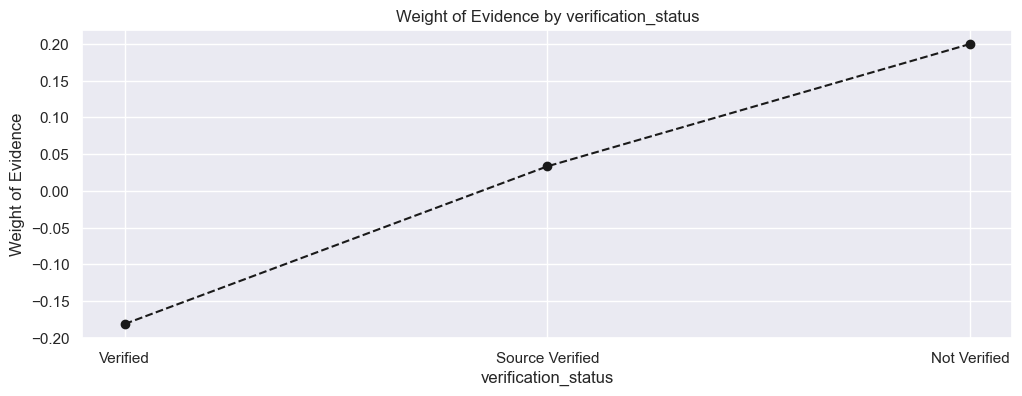

In [127]:
plot_by_woe(df_temp)

In [128]:
df_temp = woe_discrete(df_inputs_prepr, 'purpose', df_targets_prepr)
# We calculate weight of evidence.
df_temp

,purpose,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,small_business,1381,0.792180,0.014809,1094.0,287.0,0.013163,0.028290,-0.765094,NaN,NaN,0.036265
1,renewable_energy,64,0.843750,0.000686,54.0,10.0,0.000650,0.000986,-0.416809,0.051570,0.348285,0.036265
2,educational,85,0.847059,0.000911,72.0,13.0,0.000866,0.001281,-0.391491,0.003309,0.025318,0.036265
3,wedding,463,0.855292,0.004965,396.0,67.0,0.004765,0.006604,-0.326487,0.008233,0.065005,0.036265
4,house,467,0.862955,0.005008,403.0,64.0,0.004849,0.006309,-0.263155,0.007663,0.063332,0.036265
5,other,4688,0.864761,0.050270,4054.0,634.0,0.048778,0.062494,-0.247798,0.001806,0.015357,0.036265
6,vacation,495,0.866667,0.005308,429.0,66.0,0.005162,0.006506,-0.231406,0.001906,0.016392,0.036265
7,moving,616,0.866883,0.006605,534.0,82.0,0.006425,0.008083,-0.229532,0.000216,0.001874,0.036265
8,medical,938,0.869936,0.010058,816.0,122.0,0.009818,0.012026,-0.202815,0.003053,0.026717,0.036265
9,debt_consolidation,54814,0.886233,0.587774,48578.0,6236.0,0.584488,0.614687,-0.050376,0.016297,0.152438,0.036265


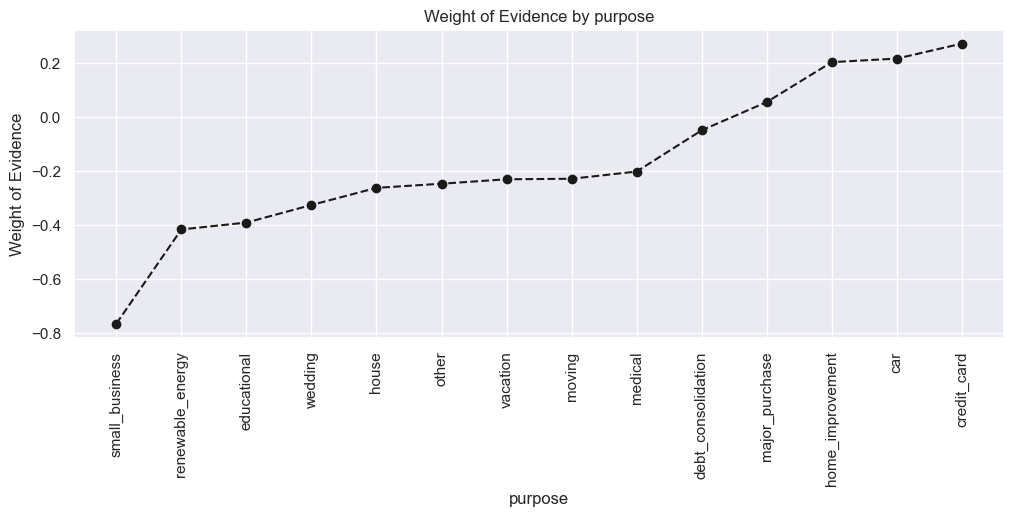

In [129]:
plot_by_woe(df_temp, 90)

In [130]:
df_inputs_prepr['purpose:educ__sm_b__wedd__ren_en__mov__house'] = _safe_sum(df_inputs_prepr, [
    'purpose:educational', 'purpose:small_business', 'purpose:wedding',
    'purpose:renewable_energy', 'purpose:moving', 'purpose:house'])
df_inputs_prepr['purpose:oth__med__vacation'] = _safe_sum(df_inputs_prepr, [
    'purpose:other', 'purpose:medical', 'purpose:vacation'])
df_inputs_prepr['purpose:major_purch__car__home_impr'] = _safe_sum(df_inputs_prepr, [
    'purpose:major_purchase', 'purpose:car', 'purpose:home_improvement'])

In [131]:
df_temp = woe_discrete(df_inputs_prepr, 'initial_list_status', df_targets_prepr)
df_temp

,initial_list_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,f,60528,0.880716,0.649045,53308.0,7220.0,0.6414,0.711681,-0.103977,NaN,NaN,0.022639
1,w,32729,0.910630,0.350955,29804.0,2925.0,0.3586,0.288319,0.218140,0.029913,0.322117,0.022639


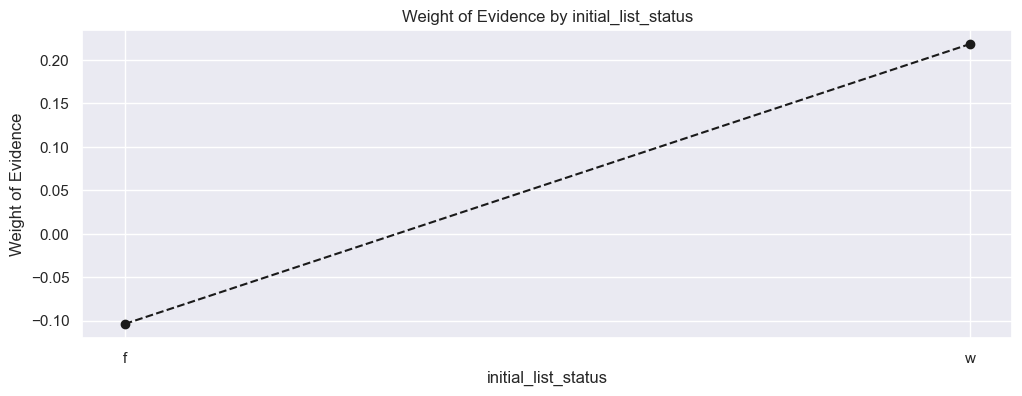

In [132]:
plot_by_woe(df_temp)

### Continous Data Preparation - WoE

In [133]:
df_inputs_prepr['term_int'].unique()

array([36, 60])

In [134]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'term_int', df_targets_prepr)
df_temp

,term_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,36,67495,0.903934,0.723753,61011.0,6484.0,0.734082,0.639133,0.138508,NaN,NaN,0.042141
1,60,25762,0.857891,0.276247,22101.0,3661.0,0.265918,0.360867,-0.305322,0.046042,0.44383,0.042141


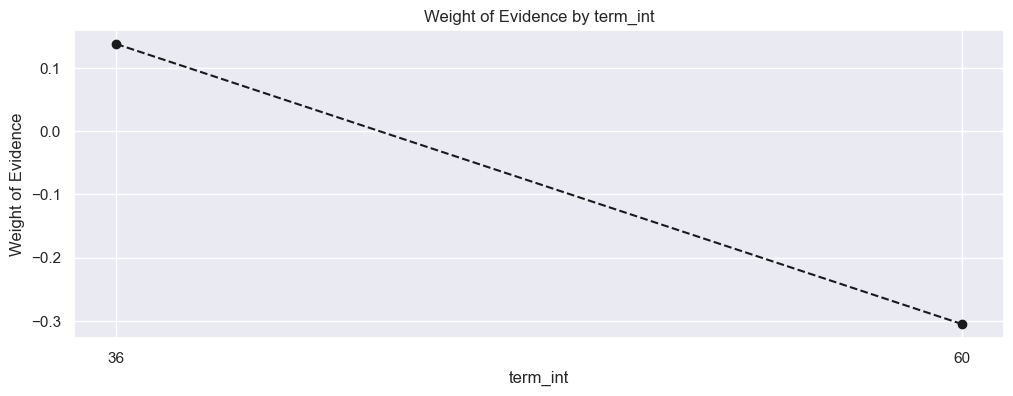

In [135]:
plot_by_woe(df_temp)

In [136]:
df_inputs_prepr['term:36'] = np.where((df_inputs_prepr['term_int']==36),1,0)
df_inputs_prepr['term:60'] = np.where((df_inputs_prepr['term_int']==60),1,0)

In [137]:
df_inputs_prepr['emp_length_int'].unique()

array([ 7, 10,  6,  1,  3,  2,  9,  4,  8,  0,  5])

In [138]:
df_temp = woe_ordered_continuous (df_inputs_prepr,'emp_length_int',df_targets_prepr)
df_temp

,emp_length_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0,11426,0.871083,0.122522,9953.0,1473.0,0.119754,0.145195,-0.192635,NaN,NaN,0.009921
1,1,5816,0.892710,0.062365,5192.0,624.0,0.062470,0.061508,0.015516,0.021626,0.208151,0.009921
2,2,8370,0.890681,0.089752,7455.0,915.0,0.089698,0.090192,-0.005492,0.002029,0.021008,0.009921
3,3,7317,0.890802,0.078461,6518.0,799.0,0.078424,0.078758,-0.004246,0.000121,0.001246,0.009921
4,4,5520,0.889312,0.059191,4909.0,611.0,0.059065,0.060227,-0.019480,0.001491,0.015233,0.009921
5,5,6252,0.888196,0.067041,5553.0,699.0,0.066813,0.068901,-0.030765,0.001116,0.011286,0.009921
6,6,5334,0.880577,0.057197,4697.0,637.0,0.056514,0.062790,-0.105298,0.007618,0.074533,0.009921
7,7,5246,0.891155,0.056253,4675.0,571.0,0.056249,0.056284,-0.000613,0.010578,0.104686,0.009921
8,8,4565,0.888499,0.048951,4056.0,509.0,0.048802,0.050172,-0.027704,0.002656,0.027091,0.009921
9,9,3520,0.892045,0.037745,3140.0,380.0,0.037780,0.037457,0.008599,0.003546,0.036302,0.009921


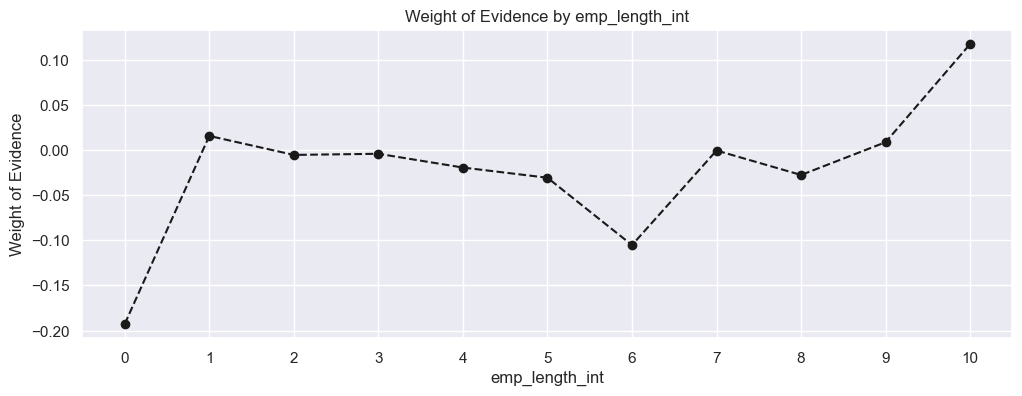

In [139]:
plot_by_woe(df_temp)

In [140]:
df_inputs_prepr['emp_length:0'] = np.where(df_inputs_prepr['emp_length_int'].isin([0]), 1, 0)
df_inputs_prepr['emp_length:1'] = np.where(df_inputs_prepr['emp_length_int'].isin([1]), 1, 0)
df_inputs_prepr['emp_length:2-4'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(2, 5)), 1, 0)
df_inputs_prepr['emp_length:5-6'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(5, 7)), 1, 0)
df_inputs_prepr['emp_length:7-9'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(7, 10)), 1, 0)
df_inputs_prepr['emp_length:10'] = np.where(df_inputs_prepr['emp_length_int'].isin([10]), 1, 0)

In [141]:
df_inputs_prepr['mths_since_issue_d'].unique()

array([ 53,  45,  50,  42,  87,  62,  57,  38,  55,  43,  39,  47,  41,
        49,  40,  44,  37,  64,  63,  69,  74,  46,  48,  52,  60,  61,
        77,  93,  59,  89,  51,  83,  65,  56, 104,  81,  98,  54,  75,
        70,  66,  58,  36,  80,  68,  88,  67,  91, 100,  72, 102,  94,
        71, 114,  73, 103,  95, 116,  84, 117,  82,  79,  96, 107,  85,
       106,  92,  90, 101,  86,  76,  78,  97, 113, 112, 119,  99, 118,
       108, 109, 105, 123, 110, 120, 121, 115, 122, 125, 124, 111, 126])

In [142]:
df_inputs_prepr['mths_since_issue_d_factor'] = pd.cut(df_inputs_prepr['mths_since_issue_d'],50)

In [ ]:
df_inputs_prepr['mths_since_issue_d_factor']

115315     (52.2, 54.0]
420540     (43.2, 45.0]
76957      (48.6, 50.4]
114743     (52.2, 54.0]
365207     (41.4, 43.2]
              ...      
312682     (37.8, 39.6]
165513     (57.6, 59.4]
242391    (35.91, 37.8]
166140     (57.6, 59.4]
195336     (61.2, 63.0]
Name: mths_since_issue_d_factor, Length: 93257, dtype: category
Categories (50, interval[float64, right]): [(35.91, 37.8] < (37.8, 39.6] < (39.6, 41.4] < (41.4, 43.2] ... (118.8, 120.6] < (120.6, 122.4] < (122.4, 124.2] < (124.2, 126.0]]

In [144]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'mths_since_issue_d_factor', df_targets_prepr)
df_temp

,mths_since_issue_d_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(35.91, 37.8]",7040,0.942045,0.075490,6632.0,408.0,0.079796,4.021686e-02,0.685186,NaN,NaN,0.117861
1,"(37.8, 39.6]",9763,0.929837,0.104689,9078.0,685.0,0.109226,6.752095e-02,0.480982,0.012208,0.204204,0.117861
2,"(39.6, 41.4]",9702,0.921666,0.104035,8942.0,760.0,0.107590,7.491375e-02,0.361988,0.008172,0.118994,0.117861
3,"(41.4, 43.2]",7333,0.907950,0.078632,6658.0,675.0,0.080109,6.653524e-02,0.185654,0.013715,0.176334,0.117861
4,"(43.2, 45.0]",7306,0.901861,0.078343,6589.0,717.0,0.079279,7.067521e-02,0.114873,0.006089,0.070781,0.117861
5,"(45.0, 46.8]",3050,0.892131,0.032705,2721.0,329.0,0.032739,3.242977e-02,0.009489,0.009730,0.105384,0.117861
6,"(46.8, 48.6]",6116,0.892413,0.065582,5458.0,658.0,0.065670,6.485954e-02,0.012425,0.000282,0.002936,0.117861
7,"(48.6, 50.4]",5790,0.887392,0.062086,5138.0,652.0,0.061820,6.426811e-02,-0.038834,0.005021,0.051258,0.117861
8,"(50.4, 52.2]",5024,0.878782,0.053873,4415.0,609.0,0.053121,6.002957e-02,-0.122263,0.008610,0.083430,0.117861
9,"(52.2, 54.0]",4541,0.871394,0.048693,3957.0,584.0,0.047610,5.756530e-02,-0.189868,0.007388,0.067604,0.117861


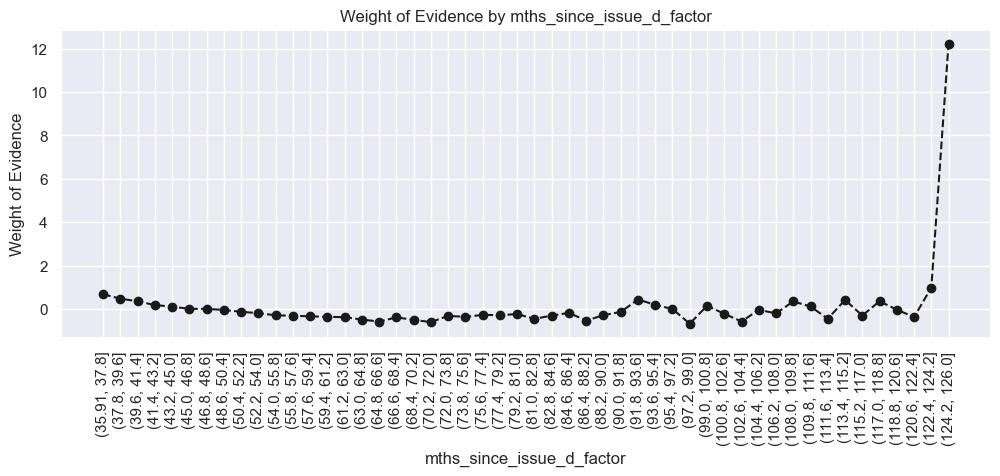

In [145]:
plot_by_woe(df_temp, 90)

In [146]:
# '< 9.548', '9.548 - 12.025', '12.025 - 15.74', '15.74 - 20.281', '> 20.281'
df_inputs_prepr['int_rate:<9.548'] = np.where((df_inputs_prepr['int_rate'] <= 9.548), 1, 0)
df_inputs_prepr['int_rate:9.548-12.025'] = np.where((df_inputs_prepr['int_rate'] > 9.548) & (df_inputs_prepr['int_rate'] <= 12.025), 1, 0)
df_inputs_prepr['int_rate:12.025-15.74'] = np.where((df_inputs_prepr['int_rate'] > 12.025) & (df_inputs_prepr['int_rate'] <= 15.74), 1, 0)
df_inputs_prepr['int_rate:15.74-20.281'] = np.where((df_inputs_prepr['int_rate'] > 15.74) & (df_inputs_prepr['int_rate'] <= 20.281), 1, 0)
df_inputs_prepr['int_rate:>20.281'] = np.where((df_inputs_prepr['int_rate'] > 20.281), 1, 0)

In [147]:
df_inputs_prepr['funded_amnt_factor'] = pd.cut(df_inputs_prepr['funded_amnt'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'funded_amnt_factor', df_targets_prepr)
# We calculate weight of evidence.
df_temp

,funded_amnt_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(465.5, 1190.0]",291,0.907216,0.003120,264.0,27.0,0.003176,0.002661,0.176904,NaN,NaN,0.021405
1,"(1190.0, 1880.0]",788,0.902284,0.008450,711.0,77.0,0.008555,0.007590,0.119659,0.004932,0.057245,0.021405
2,"(1880.0, 2570.0]",1506,0.899734,0.016149,1355.0,151.0,0.016303,0.014884,0.091069,0.002550,0.028590,0.021405
3,"(2570.0, 3260.0]",1804,0.888581,0.019344,1603.0,201.0,0.019287,0.019813,-0.026881,0.011153,0.117950,0.021405
4,"(3260.0, 3950.0]",1207,0.880696,0.012943,1063.0,144.0,0.012790,0.014194,-0.104171,0.007885,0.077290,0.021405
5,"(3950.0, 4640.0]",2306,0.884215,0.024727,2039.0,267.0,0.024533,0.026318,-0.070242,0.003519,0.033929,0.021405
6,"(4640.0, 5330.0]",3995,0.898874,0.042839,3591.0,404.0,0.043207,0.039823,0.081563,0.014659,0.151805,0.021405
7,"(5330.0, 6020.0]",4284,0.907330,0.045938,3887.0,397.0,0.046768,0.039133,0.178249,0.008456,0.096686,0.021405
8,"(6020.0, 6710.0]",1706,0.893904,0.018294,1525.0,181.0,0.018349,0.017841,0.028045,0.013426,0.150204,0.021405
9,"(6710.0, 7400.0]",2960,0.896959,0.031740,2655.0,305.0,0.031945,0.030064,0.060680,0.003056,0.032635,0.021405


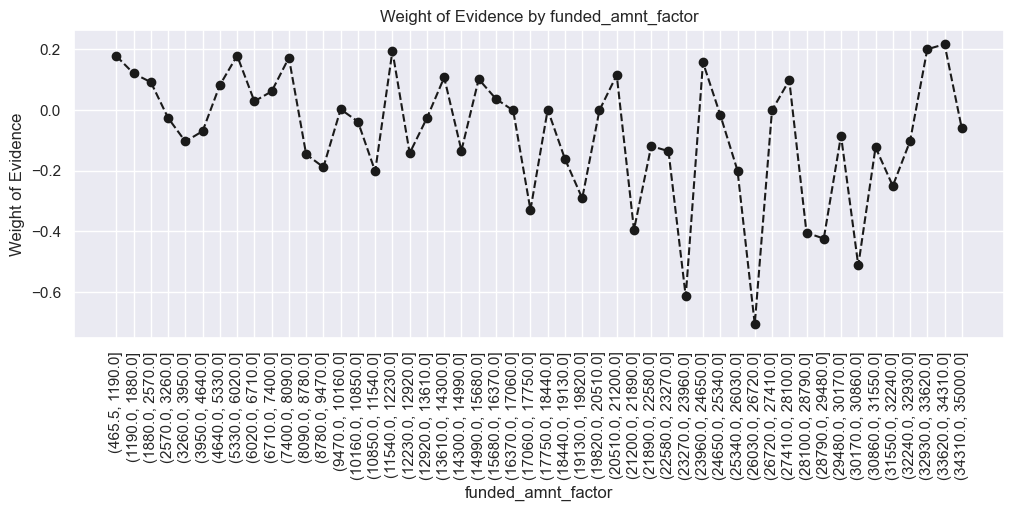

In [148]:
plot_by_woe(df_temp, 90)

In [149]:
df_inputs_prepr['mths_since_earliest_cr_line_factor'] = pd.cut(df_inputs_prepr['mths_since_earliest_cr_line'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'mths_since_earliest_cr_line_factor', df_targets_prepr)
# We calculate weight of evidence.
df_temp

,mths_since_earliest_cr_line_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.587, 11.74]",3,1.000000,0.000032,3.0,0.0,0.000036,1.000000e-09,10.493934,NaN,NaN,0.027133
1,"(11.74, 23.48]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027133
2,"(23.48, 35.22]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027133
3,"(35.22, 46.96]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027133
4,"(46.96, 58.7]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027133
5,"(58.7, 70.44]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027133
6,"(70.44, 82.18]",166,0.891566,0.001780,148.0,18.0,0.001781,1.774273e-03,0.003632,NaN,NaN,0.027133
7,"(82.18, 93.92]",506,0.891304,0.005426,451.0,55.0,0.005426,5.421390e-03,0.000926,0.000262,0.002706,0.027133
8,"(93.92, 105.66]",687,0.863173,0.007367,593.0,94.0,0.007135,9.265648e-03,-0.261309,0.028131,0.262235,0.027133
9,"(105.66, 117.4]",1263,0.855107,0.013543,1080.0,183.0,0.012995,1.803844e-02,-0.327978,0.008066,0.066669,0.027133


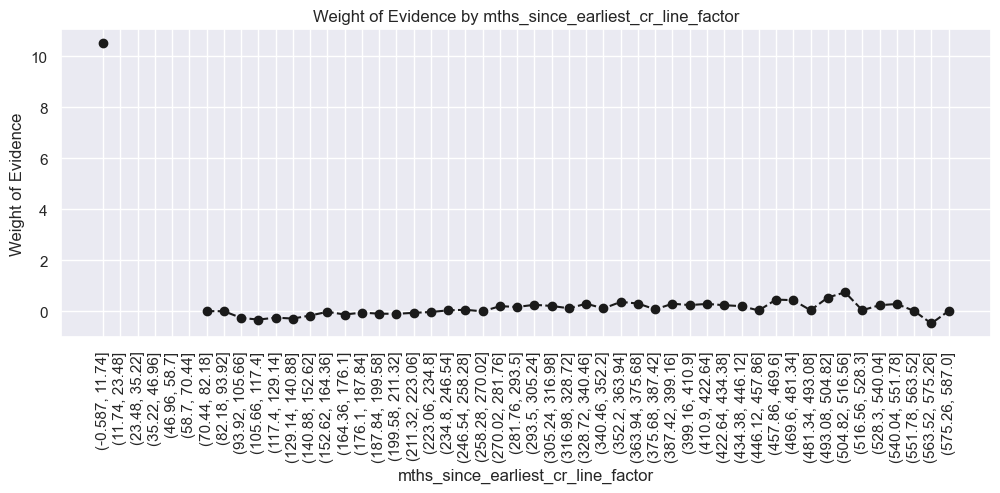

In [150]:
plot_by_woe(df_temp, 90)

In [151]:
# FIX: range() doesn't work for float values and misses the max value.
# Replaced with >= / < comparison operators.
df_inputs_prepr['mths_since_earliest_cr_line:<140']    = np.where(df_inputs_prepr['mths_since_earliest_cr_line'] < 140, 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:141-164'] = np.where((df_inputs_prepr['mths_since_earliest_cr_line'] >= 140) & (df_inputs_prepr['mths_since_earliest_cr_line'] <= 164), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:165-247'] = np.where((df_inputs_prepr['mths_since_earliest_cr_line'] >= 165) & (df_inputs_prepr['mths_since_earliest_cr_line'] <= 247), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:248-270'] = np.where((df_inputs_prepr['mths_since_earliest_cr_line'] >= 248) & (df_inputs_prepr['mths_since_earliest_cr_line'] <= 270), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:271-352'] = np.where((df_inputs_prepr['mths_since_earliest_cr_line'] >= 271) & (df_inputs_prepr['mths_since_earliest_cr_line'] <= 352), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:>352']    = np.where(df_inputs_prepr['mths_since_earliest_cr_line'] > 352, 1, 0)

In [152]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'delinq_2yrs', df_targets_prepr)
# We calculate weight of evidence.
df_temp

,delinq_2yrs,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,76642,0.891300,0.821836,68311.0,8331.0,8.219150e-01,8.211927e-01,0.000879,NaN,NaN,0.005829
1,1.0,11205,0.891656,0.120152,9991.0,1214.0,1.202113e-01,1.196649e-01,0.004556,0.000356,0.003677,0.005829
2,2.0,3249,0.895968,0.034839,2911.0,338.0,3.502503e-02,3.331690e-02,0.049998,0.004312,0.045442,0.005829
3,3.0,1155,0.880519,0.012385,1017.0,138.0,1.223650e-02,1.360276e-02,-0.105849,0.015449,0.155847,0.005829
4,4.0,475,0.867368,0.005093,412.0,63.0,4.957166e-03,6.209956e-03,-0.225319,0.013151,0.119470,0.005829
5,5.0,241,0.900415,0.002584,217.0,24.0,2.610935e-03,2.365697e-03,0.098635,0.033047,0.323955,0.005829
6,6.0,118,0.906780,0.001265,107.0,11.0,1.287419e-03,1.084278e-03,0.171725,0.006365,0.073090,0.005829
7,7.0,74,0.878378,0.000794,65.0,9.0,7.820772e-04,8.871365e-04,-0.126045,0.028401,0.297771,0.005829
8,8.0,39,0.871795,0.000418,34.0,5.0,4.090865e-04,4.928536e-04,-0.186286,0.006584,0.060240,0.005829
9,9.0,19,0.842105,0.000204,16.0,3.0,1.925113e-04,2.957122e-04,-0.429232,0.029690,0.242946,0.005829


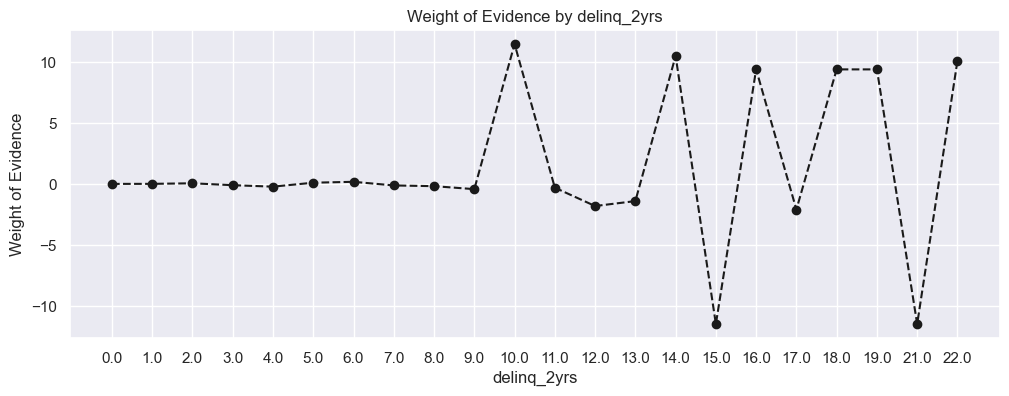

In [153]:
plot_by_woe(df_temp)

In [154]:
df_inputs_prepr['delinq_2yrs:0']   = np.where((df_inputs_prepr['delinq_2yrs'] == 0), 1, 0)
df_inputs_prepr['delinq_2yrs:1-3'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 1) & (df_inputs_prepr['delinq_2yrs'] <= 3), 1, 0)
df_inputs_prepr['delinq_2yrs:>=4'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 4), 1, 0)  # FIX: was >= 9

In [155]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'inq_last_6mths', df_targets_prepr)
# We calculate weight of evidence.
df_temp

,inq_last_6mths,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,48210,0.908256,0.516959,43787.0,4423.0,0.526843,4.359783e-01,0.189311,NaN,NaN,0.047656
1,1.0,26165,0.884693,0.280569,23148.0,3017.0,0.278516,2.973879e-01,-0.065563,0.023562,0.254873,0.047656
2,2.0,11527,0.862931,0.123605,9947.0,1580.0,0.119682,1.557417e-01,-0.263362,0.021763,0.197799,0.047656
3,3.0,5037,0.834624,0.054012,4204.0,833.0,0.050582,8.210941e-02,-0.484450,0.028307,0.221088,0.047656
4,4.0,1391,0.868440,0.014916,1208.0,183.0,0.014535,1.803844e-02,-0.215973,0.033816,0.268477,0.047656
5,5.0,592,0.875000,0.006348,518.0,74.0,0.006233,7.294234e-03,-0.157298,0.006560,0.058675,0.047656
6,6.0,240,0.866667,0.002574,208.0,32.0,0.002503,3.154263e-03,-0.231406,0.008333,0.074108,0.047656
7,7.0,43,0.953488,0.000461,41.0,2.0,0.000493,1.971414e-04,0.917217,0.086822,1.148623,0.047656
8,8.0,30,0.966667,0.000322,29.0,1.0,0.000349,9.857072e-05,1.264088,0.013178,0.346871,0.047656
9,9.0,7,1.000000,0.000075,7.0,0.0,0.000084,1.000000e-09,11.341232,0.033333,10.077144,0.047656


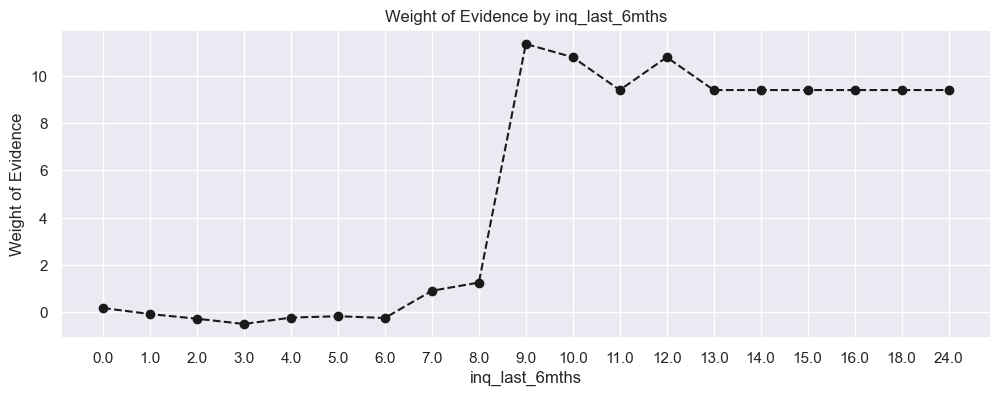

In [156]:
plot_by_woe(df_temp)

In [157]:
df_inputs_prepr['inq_last_6mths:0'] = np.where((df_inputs_prepr['inq_last_6mths'] == 0), 1, 0)
df_inputs_prepr['inq_last_6mths:1-2'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 1) & (df_inputs_prepr['inq_last_6mths'] <= 2), 1, 0)
df_inputs_prepr['inq_last_6mths:3-6'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 3) & (df_inputs_prepr['inq_last_6mths'] <= 6), 1, 0)
df_inputs_prepr['inq_last_6mths:>6'] = np.where((df_inputs_prepr['inq_last_6mths'] > 6), 1, 0)

In [158]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'open_acc', df_targets_prepr)
# We calculate weight of evidence.
df_temp

,open_acc,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,6,0.666667,0.000064,4.0,2.0,0.000048,1.971414e-04,-1.410061,NaN,NaN,0.009795
1,1.0,29,0.965517,0.000311,28.0,1.0,0.000337,9.857072e-05,1.228996,0.298851,2.639057,0.009795
2,2.0,349,0.848138,0.003742,296.0,53.0,0.003561,5.224248e-03,-0.383141,0.117380,1.612137,0.009795
3,3.0,1117,0.871083,0.011978,973.0,144.0,0.011707,1.419418e-02,-0.192637,0.022946,0.190503,0.009795
4,4.0,2485,0.892153,0.026647,2217.0,268.0,0.026675,2.641695e-02,0.009715,0.021070,0.202352,0.009795
5,5.0,4183,0.896964,0.044855,3752.0,431.0,0.045144,4.248398e-02,0.060728,0.004811,0.051013,0.009795
6,6.0,6245,0.885669,0.066965,5531.0,714.0,0.066549,7.037950e-02,-0.055967,0.011295,0.116695,0.009795
7,7.0,7511,0.893090,0.080541,6708.0,803.0,0.080710,7.915229e-02,0.019493,0.007422,0.075460,0.009795
8,8.0,8307,0.891176,0.089076,7403.0,904.0,0.089073,8.910793e-02,-0.000397,0.001914,0.019890,0.009795
9,9.0,8863,0.892587,0.095038,7911.0,952.0,0.095185,9.383933e-02,0.014236,0.001411,0.014633,0.009795


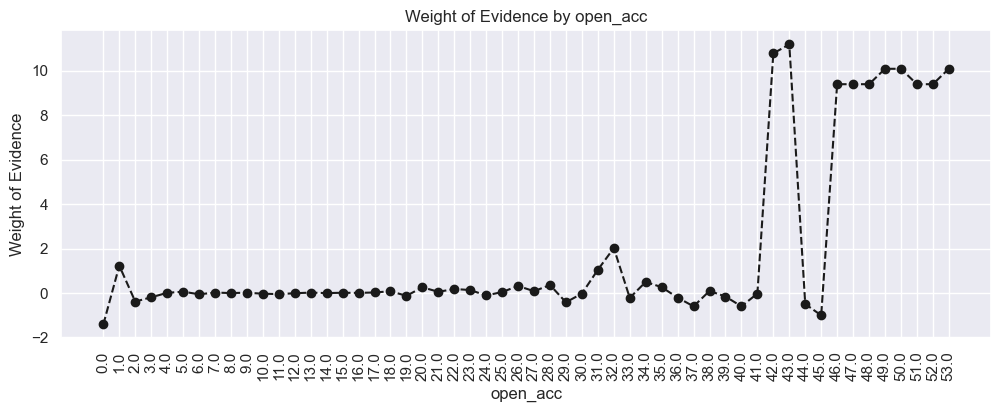

In [159]:
plot_by_woe(df_temp, 90)

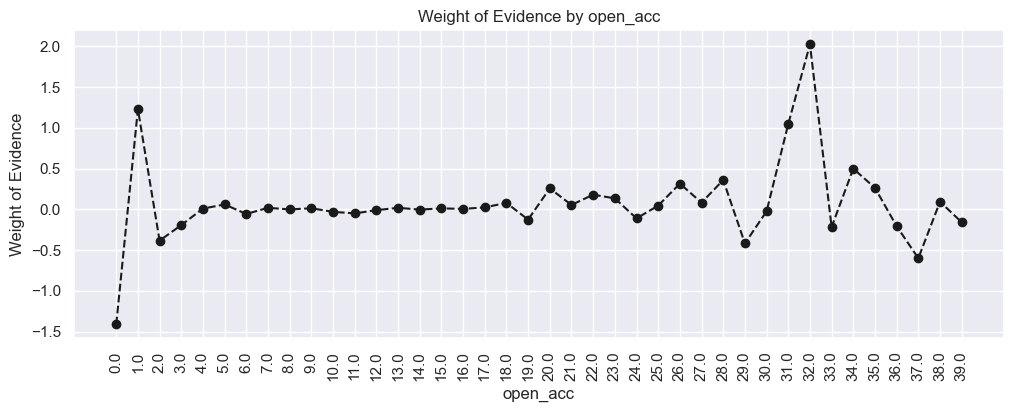

In [160]:
plot_by_woe(df_temp.iloc[ : 40, :], 90)

In [161]:
df_inputs_prepr['open_acc:0'] = np.where((df_inputs_prepr['open_acc'] == 0), 1, 0)
df_inputs_prepr['open_acc:1-3'] = np.where((df_inputs_prepr['open_acc'] >= 1) & (df_inputs_prepr['open_acc'] <= 3), 1, 0)
df_inputs_prepr['open_acc:4-12'] = np.where((df_inputs_prepr['open_acc'] >= 4) & (df_inputs_prepr['open_acc'] <= 12), 1, 0)
df_inputs_prepr['open_acc:13-17'] = np.where((df_inputs_prepr['open_acc'] >= 13) & (df_inputs_prepr['open_acc'] <= 17), 1, 0)
df_inputs_prepr['open_acc:18-22'] = np.where((df_inputs_prepr['open_acc'] >= 18) & (df_inputs_prepr['open_acc'] <= 22), 1, 0)
df_inputs_prepr['open_acc:23-25'] = np.where((df_inputs_prepr['open_acc'] >= 23) & (df_inputs_prepr['open_acc'] <= 25), 1, 0)
df_inputs_prepr['open_acc:26-30'] = np.where((df_inputs_prepr['open_acc'] >= 26) & (df_inputs_prepr['open_acc'] <= 30), 1, 0)
df_inputs_prepr['open_acc:>=31'] = np.where((df_inputs_prepr['open_acc'] >= 31), 1, 0)

In [162]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'pub_rec', df_targets_prepr)
df_temp

,pub_rec,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,80922,0.890116,0.867731,72030.0,8892.0,0.866662,8.764909e-01,-0.011277,NaN,NaN,0.003489
1,1.0,10640,0.896429,0.114093,9538.0,1102.0,0.114761,1.086249e-01,0.054949,0.006312,0.066226,0.003489
2,2.0,1168,0.900685,0.012525,1052.0,116.0,0.012658,1.143420e-02,0.101650,0.004256,0.046701,0.003489
3,3.0,315,0.926984,0.003378,292.0,23.0,0.003513,2.267127e-03,0.438051,0.026299,0.336401,0.003489
4,4.0,104,0.932692,0.001115,97.0,7.0,0.001167,6.899951e-04,0.525593,0.005708,0.087541,0.003489
5,5.0,60,0.950000,0.000643,57.0,3.0,0.000686,2.957122e-04,0.841231,0.017308,0.315638,0.003489
6,6.0,19,0.947368,0.000204,18.0,1.0,0.000217,9.857072e-05,0.787164,0.002632,0.054067,0.003489
7,7.0,16,0.937500,0.000172,15.0,1.0,0.000180,9.857072e-05,0.604842,0.009868,0.182322,0.003489
8,8.0,5,1.000000,0.000054,5.0,0.0,0.000060,1.000000e-09,11.004759,0.062500,10.399917,0.003489
9,10.0,4,1.000000,0.000043,4.0,0.0,0.000048,1.000000e-09,10.781616,0.000000,0.223144,0.003489


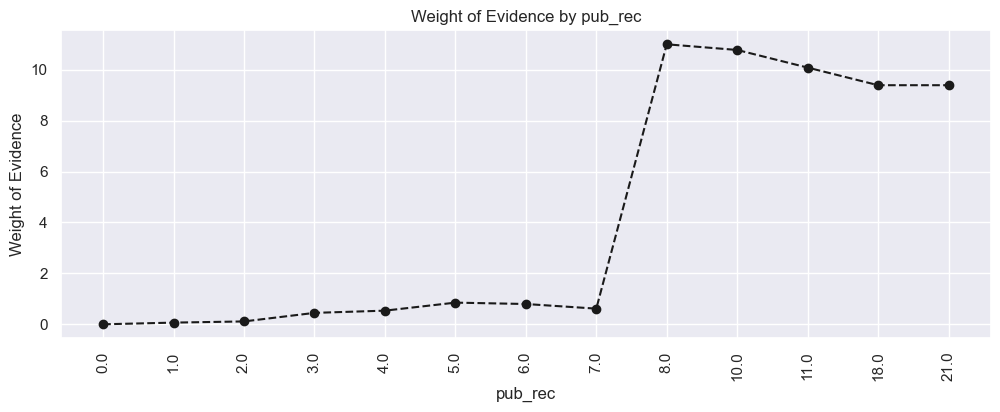

In [163]:
plot_by_woe(df_temp, 90)

In [164]:
df_inputs_prepr['pub_rec:0-2'] = np.where((df_inputs_prepr['pub_rec'] >= 0) & (df_inputs_prepr['pub_rec'] <= 2), 1, 0)
df_inputs_prepr['pub_rec:3-4'] = np.where((df_inputs_prepr['pub_rec'] >= 3) & (df_inputs_prepr['pub_rec'] <= 4), 1, 0)
df_inputs_prepr['pub_rec:>=5'] = np.where((df_inputs_prepr['pub_rec'] >= 5), 1, 0)

In [165]:
df_inputs_prepr['total_acc_factor'] = pd.cut(df_inputs_prepr['total_acc'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'total_acc_factor', df_targets_prepr)
# We calculate weight of evidence.
df_temp

,total_acc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.105, 2.1]",23,0.913043,0.000247,21.0,2.0,0.000253,1.971414e-04,0.248167,NaN,NaN,0.016504
1,"(2.1, 4.2]",381,0.824147,0.004085,314.0,67.0,0.003778,6.604239e-03,-0.558508,0.088896,0.806675,0.016504
2,"(4.2, 6.3]",1148,0.877178,0.012310,1007.0,141.0,0.012116,1.389847e-02,-0.137237,0.053031,0.421271,0.016504
3,"(6.3, 8.4]",2203,0.870177,0.023623,1917.0,286.0,0.023065,2.819123e-02,-0.200683,0.007001,0.063446,0.016504
4,"(8.4, 10.5]",3357,0.882335,0.035997,2962.0,395.0,0.035639,3.893544e-02,-0.088474,0.012158,0.112209,0.016504
5,"(10.5, 12.6]",4371,0.879433,0.046870,3844.0,527.0,0.046251,5.194677e-02,-0.116140,0.002903,0.027666,0.016504
6,"(12.6, 14.7]",5383,0.886123,0.057722,4770.0,613.0,0.057392,6.042385e-02,-0.051471,0.006690,0.064668,0.016504
7,"(14.7, 16.8]",6172,0.878645,0.066183,5423.0,749.0,0.065249,7.382947e-02,-0.123543,0.007477,0.072071,0.016504
8,"(16.8, 18.9]",6587,0.892364,0.070633,5878.0,709.0,0.070724,6.988664e-02,0.011908,0.013718,0.135451,0.016504
9,"(18.9, 21.0]",10202,0.880808,0.109397,8986.0,1216.0,0.108119,1.198620e-01,-0.103107,0.011556,0.115015,0.016504


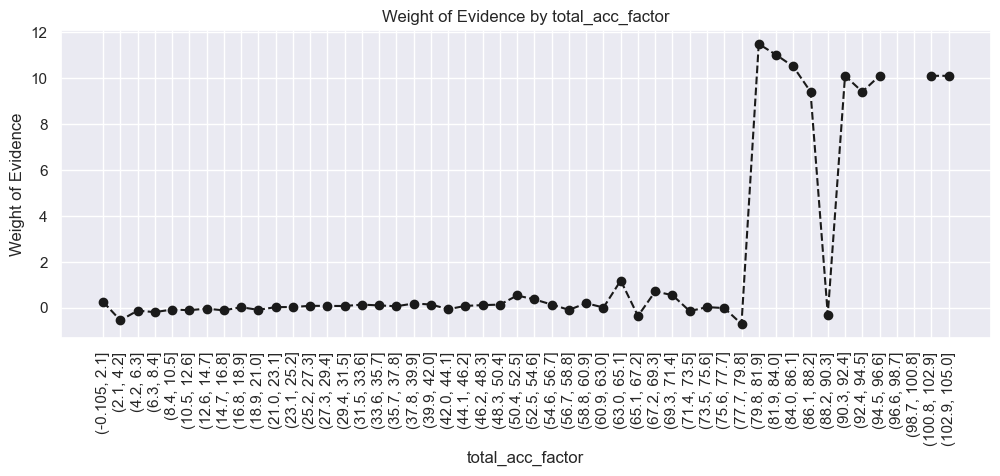

In [166]:
plot_by_woe(df_temp, 90)

In [167]:
df_inputs_prepr['total_acc:<=27'] = np.where((df_inputs_prepr['total_acc'] <= 27), 1, 0)
df_inputs_prepr['total_acc:28-51'] = np.where((df_inputs_prepr['total_acc'] >= 28) & (df_inputs_prepr['total_acc'] <= 51), 1, 0)
df_inputs_prepr['total_acc:>=52'] = np.where((df_inputs_prepr['total_acc'] >= 52), 1, 0)

In [168]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'acc_now_delinq', df_targets_prepr)
# We calculate weight of evidence.
df_temp

,acc_now_delinq,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,92930,0.891176,0.996494,82817.0,10113.0,9.964506e-01,9.968457e-01,-0.000396,NaN,NaN,0.001664
1,1.0,301,0.900332,0.003228,271.0,30.0,3.260660e-03,2.957122e-03,0.097713,0.009156,0.098110,0.001664
2,2.0,22,0.954545,0.000236,21.0,1.0,2.526711e-04,9.857072e-05,0.941314,0.054213,0.843601,0.001664
3,3.0,2,1.000000,0.000021,2.0,0.0,2.406391e-05,1.000000e-09,10.088469,0.045455,9.147154,0.001664
4,4.0,1,1.000000,0.000011,1.0,0.0,1.203196e-05,1.000000e-09,9.395321,0.000000,0.693147,0.001664
5,5.0,1,0.000000,0.000011,0.0,1.0,1.000000e-09,9.857072e-05,-11.498530,1.000000,20.893851,0.001664


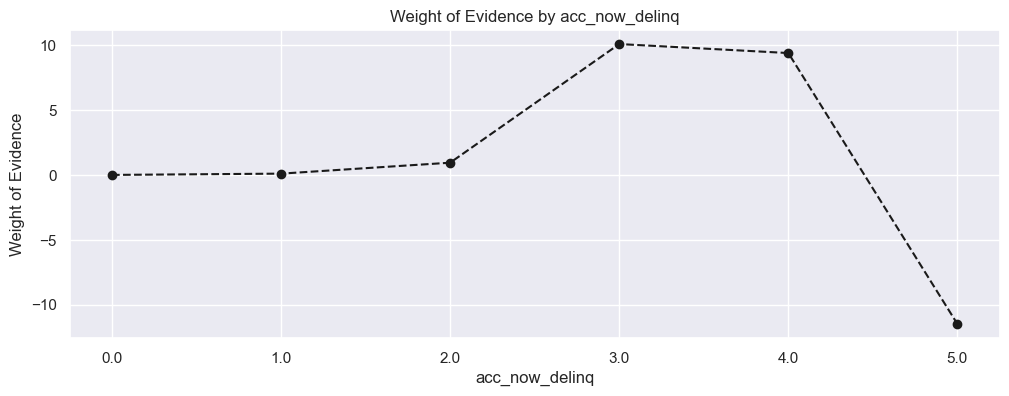

In [169]:
plot_by_woe(df_temp)

In [170]:
df_inputs_prepr['acc_now_delinq:0'] = np.where((df_inputs_prepr['acc_now_delinq'] == 0), 1, 0)
df_inputs_prepr['acc_now_delinq:>=1'] = np.where((df_inputs_prepr['acc_now_delinq'] >= 1), 1, 0)

In [171]:
df_inputs_prepr['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr['total_rev_hi_lim'], 2000)
# Here we do fine-classing: using the 'cut' method, we split the variable into 2000 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'total_rev_hi_lim_factor', df_targets_prepr)
# We calculate weight of evidence.
df_temp

,total_rev_hi_lim_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-9999.999, 5000.0]",4833,0.866543,0.051825,4188.0,645.0,0.050390,6.357812e-02,-0.232480,NaN,NaN,0.108397
1,"(5000.0, 9999.999]",13184,0.878034,0.141373,11576.0,1608.0,0.139282,1.585017e-01,-0.129265,0.011491,0.103215,0.108397
2,"(9999.999, 14999.998]",14792,0.879191,0.158615,13005.0,1787.0,0.156476,1.761459e-01,-0.118412,0.001157,0.010853,0.108397
3,"(14999.998, 19999.998]",12856,0.878034,0.137856,11288.0,1568.0,0.135817,1.545589e-01,-0.129269,0.001158,0.010856,0.108397
4,"(19999.998, 24999.997]",10473,0.882937,0.112303,9247.0,1226.0,0.111260,1.208477e-01,-0.082666,0.004903,0.046603,0.108397
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,"(9974999.002, 9979999.002]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.108397
1996,"(9979999.002, 9984999.002]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.108397
1997,"(9984999.002, 9989999.001]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.108397
1998,"(9989999.001, 9994999.0]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.108397


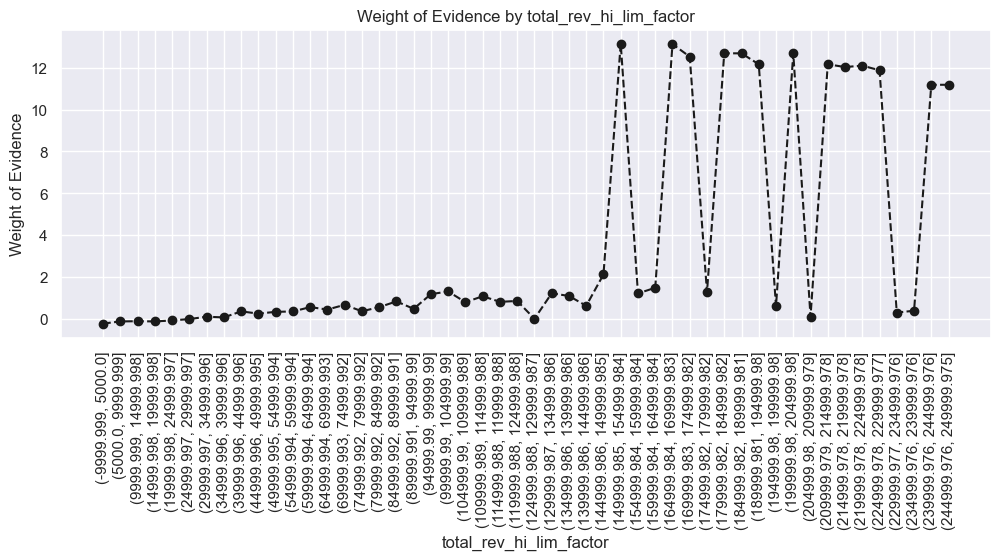

In [172]:
plot_by_woe(df_temp.iloc[: 50, : ], 90)

In [173]:
df_inputs_prepr['total_rev_hi_lim:<=5K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] <= 5000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:5K-10K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 5000) & (df_inputs_prepr['total_rev_hi_lim'] <= 10000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:10K-20K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 10000) & (df_inputs_prepr['total_rev_hi_lim'] <= 20000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:20K-30K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 20000) & (df_inputs_prepr['total_rev_hi_lim'] <= 30000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:30K-40K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 30000) & (df_inputs_prepr['total_rev_hi_lim'] <= 40000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:40K-55K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 40000) & (df_inputs_prepr['total_rev_hi_lim'] <= 55000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:55K-95K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 55000) & (df_inputs_prepr['total_rev_hi_lim'] <= 95000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:>95K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 95000), 1, 0)

In [174]:
df_inputs_prepr['installment_factor'] = pd.cut(df_inputs_prepr['installment'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'installment_factor', df_targets_prepr)
# We calculate weight of evidence.
df_temp

,installment_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(14.359, 43.575]",447,0.908277,0.004793,406.0,41.0,0.004885,0.004041,0.189573,NaN,NaN,0.01744
1,"(43.575, 71.4]",1226,0.902121,0.013146,1106.0,120.0,0.013307,0.011828,0.117805,0.006157,0.071768,0.01744
2,"(71.4, 99.226]",1714,0.897900,0.018379,1539.0,175.0,0.018517,0.017250,0.070894,0.004221,0.046911,0.01744
3,"(99.226, 127.051]",2284,0.891419,0.024491,2036.0,248.0,0.024497,0.024446,0.002106,0.006481,0.068789,0.01744
4,"(127.051, 154.876]",2553,0.888367,0.027376,2268.0,285.0,0.027288,0.028093,-0.029044,0.003052,0.031149,0.01744
5,"(154.876, 182.701]",4212,0.896961,0.045166,3778.0,434.0,0.045457,0.042780,0.060697,0.008594,0.089741,0.01744
6,"(182.701, 210.526]",4284,0.905696,0.045938,3880.0,404.0,0.046684,0.039823,0.158967,0.008735,0.098270,0.01744
7,"(210.526, 238.352]",3742,0.900321,0.040126,3369.0,373.0,0.040536,0.036767,0.097585,0.005375,0.061383,0.01744
8,"(238.352, 266.177]",4581,0.907007,0.049122,4155.0,426.0,0.049993,0.041991,0.174420,0.006687,0.076836,0.01744
9,"(266.177, 294.002]",5063,0.887221,0.054291,4492.0,571.0,0.054048,0.056284,-0.040544,0.019786,0.214964,0.01744


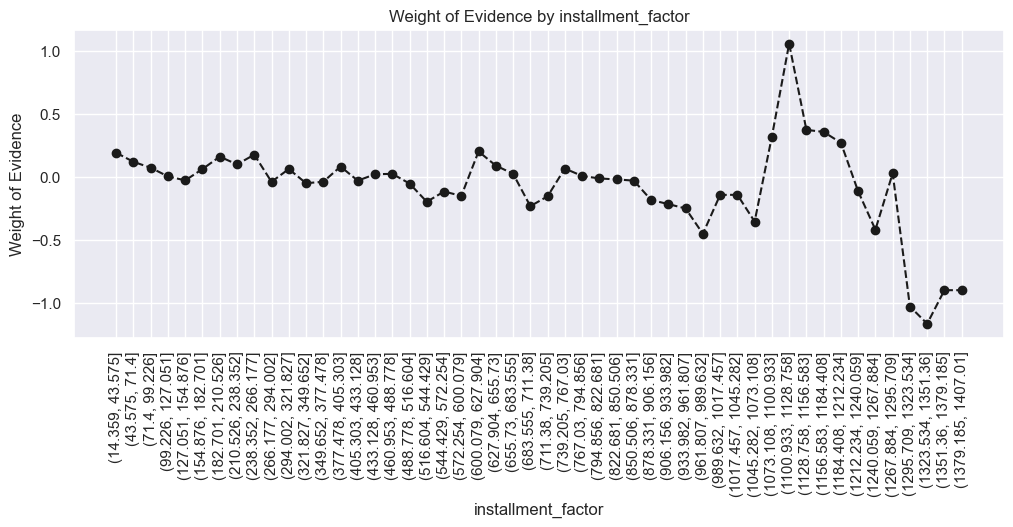

In [175]:
plot_by_woe(df_temp, 90)

In [176]:
df_inputs_prepr_temp = df_inputs_prepr.loc[df_inputs_prepr['annual_inc'] <= 140000,:  ]
df_inputs_prepr_temp ['annual_inc_factor'] = pd.cut(df_inputs_prepr_temp['annual_inc'],50)
df_temp = woe_ordered_continuous (df_inputs_prepr_temp, 'annual_inc_factor', df_targets_prepr[df_inputs_prepr_temp.index])
df_temp

/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/1788206236.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp ['annual_inc_factor'] = pd.cut(df_inputs_prepr_temp['annual_inc'],50)


,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(2863.0, 5740.0]",7,1.000000,0.000080,7.0,0.0,0.000090,1.000000e-09,11.404609,NaN,NaN,0.065153
1,"(5740.0, 8480.0]",12,0.916667,0.000137,11.0,1.0,0.000141,1.028066e-04,0.315989,0.083333,11.088620,0.065153
2,"(8480.0, 11220.0]",96,0.843750,0.001094,81.0,15.0,0.001038,1.542099e-03,-0.395507,0.072917,0.711496,0.065153
3,"(11220.0, 13960.0]",175,0.834286,0.001995,146.0,29.0,0.001872,2.981392e-03,-0.465595,0.009464,0.070088,0.065153
4,"(13960.0, 16700.0]",361,0.853186,0.004115,308.0,53.0,0.003948,5.448751e-03,-0.322098,0.018900,0.143497,0.065153
5,"(16700.0, 19440.0]",417,0.839329,0.004753,350.0,67.0,0.004487,6.888044e-03,-0.428665,0.013857,0.106567,0.065153
6,"(19440.0, 22180.0]",867,0.839677,0.009882,728.0,139.0,0.009332,1.429012e-02,-0.426079,0.000349,0.002587,0.065153
7,"(22180.0, 24920.0]",828,0.861111,0.009438,713.0,115.0,0.009140,1.182276e-02,-0.257357,0.021434,0.168722,0.065153
8,"(24920.0, 27660.0]",1778,0.850956,0.020266,1513.0,265.0,0.019395,2.724375e-02,-0.339786,0.010155,0.082429,0.065153
9,"(27660.0, 30400.0]",2588,0.866692,0.029498,2243.0,345.0,0.028753,3.546828e-02,-0.209881,0.015736,0.129905,0.065153


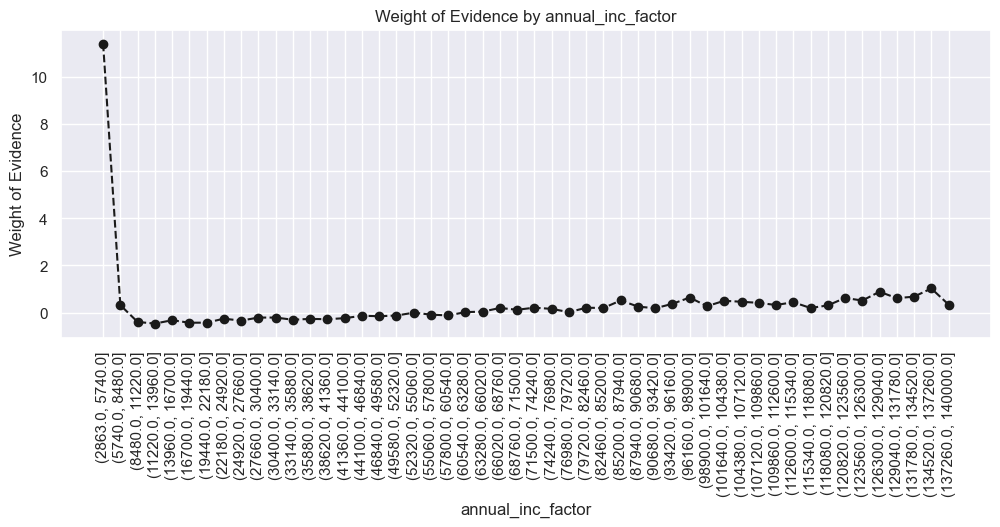

In [177]:
plot_by_woe(df_temp, 90)

In [178]:
df_inputs_prepr['annual_inc:<20K'] = np.where((df_inputs_prepr['annual_inc'] <= 20000), 1, 0)
df_inputs_prepr['annual_inc:20K-30K'] = np.where((df_inputs_prepr['annual_inc'] > 20000) & (df_inputs_prepr['annual_inc'] <= 30000), 1, 0)
df_inputs_prepr['annual_inc:30K-40K'] = np.where((df_inputs_prepr['annual_inc'] > 30000) & (df_inputs_prepr['annual_inc'] <= 40000), 1, 0)
df_inputs_prepr['annual_inc:40K-50K'] = np.where((df_inputs_prepr['annual_inc'] > 40000) & (df_inputs_prepr['annual_inc'] <= 50000), 1, 0)
df_inputs_prepr['annual_inc:50K-60K'] = np.where((df_inputs_prepr['annual_inc'] > 50000) & (df_inputs_prepr['annual_inc'] <= 60000), 1, 0)
df_inputs_prepr['annual_inc:60K-70K'] = np.where((df_inputs_prepr['annual_inc'] > 60000) & (df_inputs_prepr['annual_inc'] <= 70000), 1, 0)
df_inputs_prepr['annual_inc:70K-80K'] = np.where((df_inputs_prepr['annual_inc'] > 70000) & (df_inputs_prepr['annual_inc'] <= 80000), 1, 0)
df_inputs_prepr['annual_inc:80K-90K'] = np.where((df_inputs_prepr['annual_inc'] > 80000) & (df_inputs_prepr['annual_inc'] <= 90000), 1, 0)
df_inputs_prepr['annual_inc:90K-100K'] = np.where((df_inputs_prepr['annual_inc'] > 90000) & (df_inputs_prepr['annual_inc'] <= 100000), 1, 0)
df_inputs_prepr['annual_inc:100K-120K'] = np.where((df_inputs_prepr['annual_inc'] > 100000) & (df_inputs_prepr['annual_inc'] <= 120000), 1, 0)
df_inputs_prepr['annual_inc:120K-140K'] = np.where((df_inputs_prepr['annual_inc'] > 120000) & (df_inputs_prepr['annual_inc'] <= 140000), 1, 0)
df_inputs_prepr['annual_inc:>140K'] = np.where((df_inputs_prepr['annual_inc'] > 140000), 1, 0)

/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/932304449.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['annual_inc:120K-140K'] = np.where((df_inputs_prepr['annual_inc'] > 120000) & (df_inputs_prepr['annual_inc'] <= 140000), 1, 0)
/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/932304449.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['annual_inc:>140K'] = np.where((df_inputs_prepr['annual_inc'] > 140000), 1, 0)


In [179]:
df_inputs_prepr_temp = df_inputs_prepr[pd.notnull(df_inputs_prepr['mths_since_last_delinq'])]
df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'mths_since_last_delinq_factor', df_targets_prepr[df_inputs_prepr_temp.index])
# We calculate weight of evidence.
df_temp

/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/1338112332.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)
/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/1338112332.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)


,mths_since_last_delinq_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.18, 3.6]",1248,0.882212,0.029059,1101.0,147.0,2.871749e-02,3.190104e-02,-0.105132,NaN,NaN,0.020054
1,"(3.6, 7.2]",2728,0.895161,0.063520,2442.0,286.0,6.369493e-02,6.206597e-02,0.025907,0.012950,0.131039,0.020054
2,"(7.2, 10.8]",2554,0.890368,0.059469,2274.0,280.0,5.931297e-02,6.076389e-02,-0.024168,0.004793,0.050075,0.020054
3,"(10.8, 14.4]",3304,0.884685,0.076932,2923.0,381.0,7.624090e-02,8.268229e-02,-0.081107,0.005683,0.056940,0.020054
4,"(14.4, 18.0]",3153,0.898509,0.073416,2833.0,320.0,7.389342e-02,6.944444e-02,0.062097,0.013824,0.143204,0.020054
5,"(18.0, 21.6]",2238,0.884718,0.052111,1980.0,258.0,5.164454e-02,5.598958e-02,-0.080781,0.013791,0.142878,0.020054
6,"(21.6, 25.2]",2745,0.899454,0.063916,2469.0,276.0,6.439918e-02,5.989583e-02,0.072494,0.014735,0.153275,0.020054
7,"(25.2, 28.8]",1980,0.904040,0.046103,1790.0,190.0,4.668875e-02,4.123264e-02,0.124273,0.004587,0.051779,0.020054
8,"(28.8, 32.4]",2547,0.899490,0.059306,2291.0,256.0,5.975638e-02,5.555556e-02,0.072893,0.004551,0.051381,0.020054
9,"(32.4, 36.0]",2445,0.903067,0.056931,2208.0,237.0,5.759149e-02,5.143229e-02,0.113109,0.003578,0.040216,0.020054


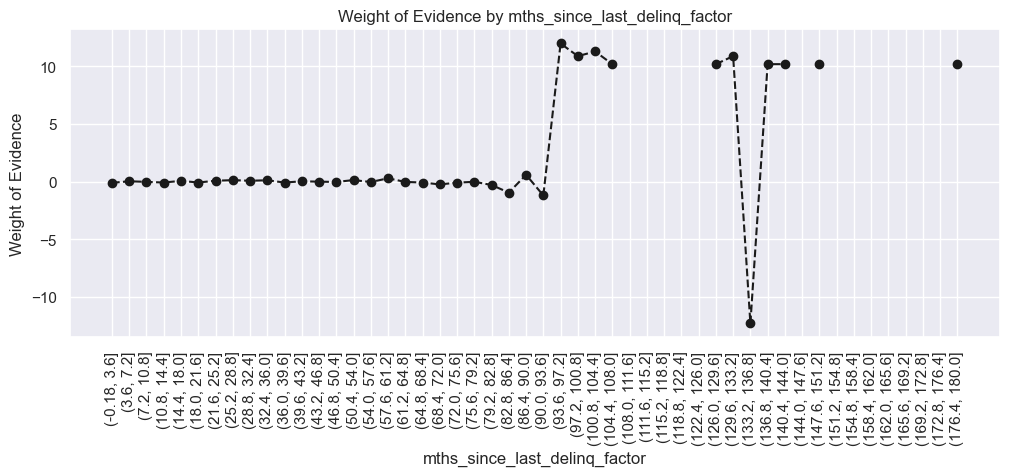

In [180]:
plot_by_woe(df_temp, 90)

In [181]:
df_inputs_prepr['mths_since_last_delinq:Missing'] = np.where((df_inputs_prepr['mths_since_last_delinq'].isnull()), 1, 0)
df_inputs_prepr['mths_since_last_delinq:0-3'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 0) & (df_inputs_prepr['mths_since_last_delinq'] <= 3), 1, 0)
df_inputs_prepr['mths_since_last_delinq:4-30'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 4) & (df_inputs_prepr['mths_since_last_delinq'] <= 30), 1, 0)
df_inputs_prepr['mths_since_last_delinq:31-56'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 31) & (df_inputs_prepr['mths_since_last_delinq'] <= 56), 1, 0)
df_inputs_prepr['mths_since_last_delinq:>=57'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 57), 1, 0)

/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/2300411631.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_delinq:Missing'] = np.where((df_inputs_prepr['mths_since_last_delinq'].isnull()), 1, 0)
/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/2300411631.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_delinq:0-3'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 0) & (df_inputs_prepr['mths_since_last_delinq'] <= 3),

In [182]:
df_inputs_prepr_temp = df_inputs_prepr.loc[df_inputs_prepr['dti'] <= 35, : ]
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_inputs_prepr_temp['dti_factor'] = pd.cut(df_inputs_prepr_temp['dti'], 50)
# We calculate weight of evidence.
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'dti_factor', df_targets_prepr[df_inputs_prepr_temp.index])

df_temp

/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/1314713147.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_temp['dti_factor'] = pd.cut(df_inputs_prepr_temp['dti'], 50)
/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/1314713147.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp['dti_factor'] = pd.cut(df_inputs_prepr_temp['dti'], 50)


,dti_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.035, 0.7]",356,0.898876,0.003846,320.0,36.0,0.003879,0.003574,0.081850,NaN,NaN,0.03224
1,"(0.7, 1.4]",409,0.914425,0.004418,374.0,35.0,0.004533,0.003475,0.265956,0.015549,0.184106,0.03224
2,"(1.4, 2.1]",494,0.906883,0.005336,448.0,46.0,0.005430,0.004567,0.173200,0.007543,0.092756,0.03224
3,"(2.1, 2.8]",654,0.915902,0.007065,599.0,55.0,0.007261,0.005460,0.284977,0.009020,0.111777,0.03224
4,"(2.8, 3.5]",832,0.915865,0.008987,762.0,70.0,0.009236,0.006949,0.284499,0.000037,0.000477,0.03224
5,"(3.5, 4.2]",955,0.906806,0.010316,866.0,89.0,0.010497,0.008836,0.172297,0.009059,0.112203,0.03224
6,"(4.2, 4.9]",1168,0.919521,0.012617,1074.0,94.0,0.013018,0.009332,0.332899,0.012714,0.160602,0.03224
7,"(4.9, 5.6]",1314,0.908676,0.014194,1194.0,120.0,0.014473,0.011913,0.194621,0.010845,0.138278,0.03224
8,"(5.6, 6.3]",1469,0.906739,0.015868,1332.0,137.0,0.016145,0.013601,0.171504,0.001937,0.023117,0.03224
9,"(6.3, 7.0]",1607,0.914126,0.017359,1469.0,138.0,0.017806,0.013700,0.262132,0.007386,0.090628,0.03224


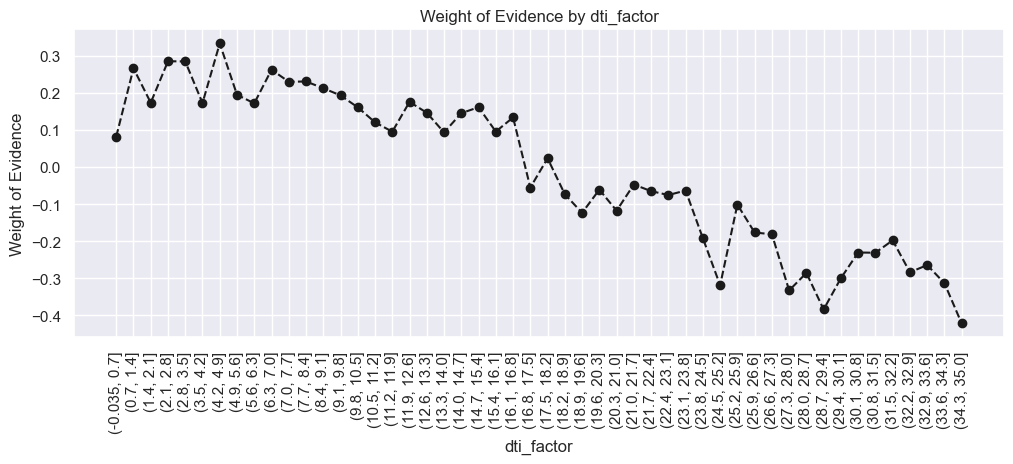

In [183]:
plot_by_woe(df_temp, 90)

In [184]:
df_inputs_prepr['dti:<=1.4'] = np.where((df_inputs_prepr['dti'] <= 1.4), 1, 0)
df_inputs_prepr['dti:1.4-3.5'] = np.where((df_inputs_prepr['dti'] > 1.4) & (df_inputs_prepr['dti'] <= 3.5), 1, 0)
df_inputs_prepr['dti:3.5-7.7'] = np.where((df_inputs_prepr['dti'] > 3.5) & (df_inputs_prepr['dti'] <= 7.7), 1, 0)
df_inputs_prepr['dti:7.7-10.5'] = np.where((df_inputs_prepr['dti'] > 7.7) & (df_inputs_prepr['dti'] <= 10.5), 1, 0)
df_inputs_prepr['dti:10.5-16.1'] = np.where((df_inputs_prepr['dti'] > 10.5) & (df_inputs_prepr['dti'] <= 16.1), 1, 0)
df_inputs_prepr['dti:16.1-20.3'] = np.where((df_inputs_prepr['dti'] > 16.1) & (df_inputs_prepr['dti'] <= 20.3), 1, 0)
df_inputs_prepr['dti:20.3-21.7'] = np.where((df_inputs_prepr['dti'] > 20.3) & (df_inputs_prepr['dti'] <= 21.7), 1, 0)
df_inputs_prepr['dti:21.7-22.4'] = np.where((df_inputs_prepr['dti'] > 21.7) & (df_inputs_prepr['dti'] <= 22.4), 1, 0)
df_inputs_prepr['dti:22.4-35'] = np.where((df_inputs_prepr['dti'] > 22.4) & (df_inputs_prepr['dti'] <= 35), 1, 0)
df_inputs_prepr['dti:>35'] = np.where((df_inputs_prepr['dti'] > 35), 1, 0)

/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/3828360169.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti:<=1.4'] = np.where((df_inputs_prepr['dti'] <= 1.4), 1, 0)
/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/3828360169.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti:1.4-3.5'] = np.where((df_inputs_prepr['dti'] > 1.4) & (df_inputs_prepr['dti'] <= 3.5), 1, 0)
/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/3828360169.py:3: Per

In [185]:
df_inputs_prepr_temp = df_inputs_prepr[pd.notnull(df_inputs_prepr['mths_since_last_record'])]
#sum(loan_data_temp['mths_since_last_record'].isnull())
df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'mths_since_last_record_factor', df_targets_prepr[df_inputs_prepr_temp.index])
# We calculate weight of evidence.
df_temp

/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/3414794372.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)
/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/3414794372.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)


,mths_since_last_record_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.121, 2.42]",235,0.876596,0.018712,206.0,29.0,0.018262,0.022674,-0.216372,NaN,NaN,0.106595
1,"(2.42, 4.84]",19,0.842105,0.001513,16.0,3.0,0.001418,0.002346,-0.502976,0.034490,0.286604,0.106595
2,"(4.84, 7.26]",45,0.955556,0.003583,43.0,2.0,0.003812,0.001564,0.891100,0.113450,1.394077,0.106595
3,"(7.26, 9.68]",39,0.974359,0.003105,38.0,1.0,0.003369,0.000782,1.460633,0.018803,0.569533,0.106595
4,"(9.68, 12.1]",70,0.871429,0.005574,61.0,9.0,0.005408,0.007037,-0.263303,0.102930,1.723937,0.106595
5,"(12.1, 14.52]",54,0.907407,0.004300,49.0,5.0,0.004344,0.003909,0.105430,0.035979,0.368733,0.106595
6,"(14.52, 16.94]",64,0.921875,0.005096,59.0,5.0,0.005230,0.003909,0.291147,0.014468,0.185717,0.106595
7,"(16.94, 19.36]",82,0.939024,0.006529,77.0,5.0,0.006826,0.003909,0.557415,0.017149,0.266268,0.106595
8,"(19.36, 21.78]",67,0.940299,0.005335,63.0,4.0,0.005585,0.003127,0.579888,0.001274,0.022473,0.106595
9,"(21.78, 24.2]",113,0.946903,0.008998,107.0,6.0,0.009486,0.004691,0.704117,0.006604,0.124229,0.106595


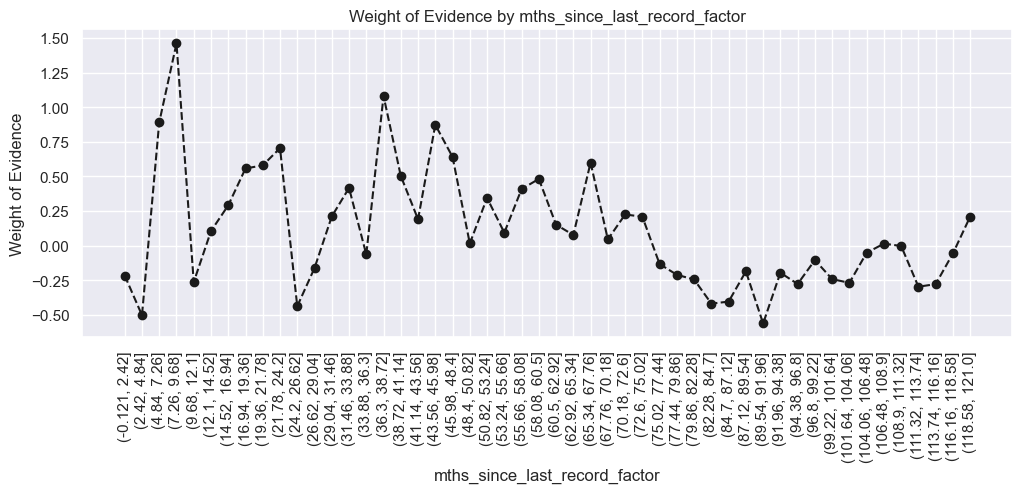

In [186]:
plot_by_woe(df_temp, 90)

In [187]:
df_inputs_prepr['mths_since_last_record:Missing'] = np.where((df_inputs_prepr['mths_since_last_record'].isnull()), 1, 0)
df_inputs_prepr['mths_since_last_record:0-2'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 0) & (df_inputs_prepr['mths_since_last_record'] <= 2), 1, 0)
df_inputs_prepr['mths_since_last_record:3-20'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 3) & (df_inputs_prepr['mths_since_last_record'] <= 20), 1, 0)
df_inputs_prepr['mths_since_last_record:21-31'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 21) & (df_inputs_prepr['mths_since_last_record'] <= 31), 1, 0)
df_inputs_prepr['mths_since_last_record:32-80'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 32) & (df_inputs_prepr['mths_since_last_record'] <= 80), 1, 0)
df_inputs_prepr['mths_since_last_record:81-86'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 81) & (df_inputs_prepr['mths_since_last_record'] <= 86), 1, 0)
df_inputs_prepr['mths_since_last_record:>=86'] = np.where((df_inputs_prepr['mths_since_last_record'] > 86), 1, 0)

/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/2438592495.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_record:Missing'] = np.where((df_inputs_prepr['mths_since_last_record'].isnull()), 1, 0)
/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_75767/2438592495.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_record:0-2'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 0) & (df_inputs_prepr['mths_since_last_record'] <= 2),

In [188]:
# Save preprocessed train set
loan_data_inputs_train = df_inputs_prepr
loan_data_inputs_train.to_csv('../data/processed/loan_data_inputs_train.csv')
targets_train.to_csv('../data/processed/loan_data_targets_train.csv')

# Now process and save test set using the same bins
df_inputs_prepr_test = inputs_test.copy()
df_targets_prepr_test = targets_test

# Apply the same grouped columns to test set
df_inputs_prepr_test['home_ownership:RENT_OTHER_NONE_ANY'] = _safe_sum(df_inputs_prepr_test, [
    'home_ownership:RENT', 'home_ownership:OTHER',
    'home_ownership:NONE', 'home_ownership:ANY'
])
if 'addr_state:ND' not in df_inputs_prepr_test.columns:
    df_inputs_prepr_test['addr_state:ND'] = 0
df_inputs_prepr_test['addr_state:ND_NE_IA_NV_FL_HI_AL'] = _safe_sum(df_inputs_prepr_test, ['addr_state:ND','addr_state:NE','addr_state:IA','addr_state:NV','addr_state:FL','addr_state:HI','addr_state:AL'])
df_inputs_prepr_test['addr_state:NM_VA']            = _safe_sum(df_inputs_prepr_test, ['addr_state:NM','addr_state:VA'])
df_inputs_prepr_test['addr_state:OK_TN_MO_LA_MD_NC']= _safe_sum(df_inputs_prepr_test, ['addr_state:OK','addr_state:TN','addr_state:MO','addr_state:LA','addr_state:MD','addr_state:NC'])
df_inputs_prepr_test['addr_state:UT_KY_AZ_NJ']      = _safe_sum(df_inputs_prepr_test, ['addr_state:UT','addr_state:KY','addr_state:AZ','addr_state:NJ'])
df_inputs_prepr_test['addr_state:AR_MI_PA_OH_MN']   = _safe_sum(df_inputs_prepr_test, ['addr_state:AR','addr_state:MI','addr_state:PA','addr_state:OH','addr_state:MN'])
df_inputs_prepr_test['addr_state:RI_MA_DE_SD_IN']   = _safe_sum(df_inputs_prepr_test, ['addr_state:RI','addr_state:MA','addr_state:DE','addr_state:SD','addr_state:IN'])
df_inputs_prepr_test['addr_state:GA_WA_OR']         = _safe_sum(df_inputs_prepr_test, ['addr_state:GA','addr_state:WA','addr_state:OR'])
df_inputs_prepr_test['addr_state:WI_MT']            = _safe_sum(df_inputs_prepr_test, ['addr_state:WI','addr_state:MT'])
df_inputs_prepr_test['addr_state:IL_CT']            = _safe_sum(df_inputs_prepr_test, ['addr_state:IL','addr_state:CT'])
df_inputs_prepr_test['addr_state:KS_SC_CO_VT_AK_MS']= _safe_sum(df_inputs_prepr_test, ['addr_state:KS','addr_state:SC','addr_state:CO','addr_state:VT','addr_state:AK','addr_state:MS'])
df_inputs_prepr_test['addr_state:WV_NH_WY_DC_ME_ID']= _safe_sum(df_inputs_prepr_test, ['addr_state:WV','addr_state:NH','addr_state:WY','addr_state:DC','addr_state:ME','addr_state:ID'])
df_inputs_prepr_test['purpose:educ__sm_b__wedd__ren_en__mov__house'] = _safe_sum(df_inputs_prepr_test, ['purpose:educational','purpose:small_business','purpose:wedding','purpose:renewable_energy','purpose:moving','purpose:house'])
df_inputs_prepr_test['purpose:oth__med__vacation']          = _safe_sum(df_inputs_prepr_test, ['purpose:other','purpose:medical','purpose:vacation'])
df_inputs_prepr_test['purpose:major_purch__car__home_impr'] = _safe_sum(df_inputs_prepr_test, ['purpose:major_purchase','purpose:car','purpose:home_improvement'])
df_inputs_prepr_test['term:36'] = np.where(df_inputs_prepr_test['term_int']==36,1,0)
df_inputs_prepr_test['term:60'] = np.where(df_inputs_prepr_test['term_int']==60,1,0)
df_inputs_prepr_test['emp_length:0']   = np.where(df_inputs_prepr_test['emp_length_int'].isin([0]),1,0)
df_inputs_prepr_test['emp_length:1']   = np.where(df_inputs_prepr_test['emp_length_int'].isin([1]),1,0)
df_inputs_prepr_test['emp_length:2-4'] = np.where(df_inputs_prepr_test['emp_length_int'].isin(range(2,5)),1,0)
df_inputs_prepr_test['emp_length:5-6'] = np.where(df_inputs_prepr_test['emp_length_int'].isin(range(5,7)),1,0)
df_inputs_prepr_test['emp_length:7-9'] = np.where(df_inputs_prepr_test['emp_length_int'].isin(range(7,10)),1,0)
df_inputs_prepr_test['emp_length:10']  = np.where(df_inputs_prepr_test['emp_length_int'].isin([10]),1,0)
df_inputs_prepr_test['int_rate:<9.548']       = np.where(df_inputs_prepr_test['int_rate']<=9.548,1,0)
df_inputs_prepr_test['int_rate:9.548-12.025'] = np.where((df_inputs_prepr_test['int_rate']>9.548)&(df_inputs_prepr_test['int_rate']<=12.025),1,0)
df_inputs_prepr_test['int_rate:12.025-15.74'] = np.where((df_inputs_prepr_test['int_rate']>12.025)&(df_inputs_prepr_test['int_rate']<=15.74),1,0)
df_inputs_prepr_test['int_rate:15.74-20.281'] = np.where((df_inputs_prepr_test['int_rate']>15.74)&(df_inputs_prepr_test['int_rate']<=20.281),1,0)
df_inputs_prepr_test['int_rate:>20.281']      = np.where(df_inputs_prepr_test['int_rate']>20.281,1,0)
df_inputs_prepr_test['mths_since_earliest_cr_line:<140']    = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line']<140,1,0)
df_inputs_prepr_test['mths_since_earliest_cr_line:141-164'] = np.where((df_inputs_prepr_test['mths_since_earliest_cr_line']>=140)&(df_inputs_prepr_test['mths_since_earliest_cr_line']<=164),1,0)
df_inputs_prepr_test['mths_since_earliest_cr_line:165-247'] = np.where((df_inputs_prepr_test['mths_since_earliest_cr_line']>=165)&(df_inputs_prepr_test['mths_since_earliest_cr_line']<=247),1,0)
df_inputs_prepr_test['mths_since_earliest_cr_line:248-270'] = np.where((df_inputs_prepr_test['mths_since_earliest_cr_line']>=248)&(df_inputs_prepr_test['mths_since_earliest_cr_line']<=270),1,0)
df_inputs_prepr_test['mths_since_earliest_cr_line:271-352'] = np.where((df_inputs_prepr_test['mths_since_earliest_cr_line']>=271)&(df_inputs_prepr_test['mths_since_earliest_cr_line']<=352),1,0)
df_inputs_prepr_test['mths_since_earliest_cr_line:>352']    = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line']>352,1,0)
df_inputs_prepr_test['delinq_2yrs:0']   = np.where(df_inputs_prepr_test['delinq_2yrs']==0,1,0)
df_inputs_prepr_test['delinq_2yrs:1-3'] = np.where((df_inputs_prepr_test['delinq_2yrs']>=1)&(df_inputs_prepr_test['delinq_2yrs']<=3),1,0)
df_inputs_prepr_test['delinq_2yrs:>=4'] = np.where(df_inputs_prepr_test['delinq_2yrs']>=4,1,0)
df_inputs_prepr_test['inq_last_6mths:0']   = np.where(df_inputs_prepr_test['inq_last_6mths']==0,1,0)
df_inputs_prepr_test['inq_last_6mths:1-2'] = np.where((df_inputs_prepr_test['inq_last_6mths']>=1)&(df_inputs_prepr_test['inq_last_6mths']<=2),1,0)
df_inputs_prepr_test['inq_last_6mths:3-6'] = np.where((df_inputs_prepr_test['inq_last_6mths']>=3)&(df_inputs_prepr_test['inq_last_6mths']<=6),1,0)
df_inputs_prepr_test['inq_last_6mths:>6']  = np.where(df_inputs_prepr_test['inq_last_6mths']>6,1,0)
df_inputs_prepr_test['open_acc:0']     = np.where(df_inputs_prepr_test['open_acc']==0,1,0)
df_inputs_prepr_test['open_acc:1-3']   = np.where((df_inputs_prepr_test['open_acc']>=1)&(df_inputs_prepr_test['open_acc']<=3),1,0)
df_inputs_prepr_test['open_acc:4-12']  = np.where((df_inputs_prepr_test['open_acc']>=4)&(df_inputs_prepr_test['open_acc']<=12),1,0)
df_inputs_prepr_test['open_acc:13-17'] = np.where((df_inputs_prepr_test['open_acc']>=13)&(df_inputs_prepr_test['open_acc']<=17),1,0)
df_inputs_prepr_test['open_acc:18-22'] = np.where((df_inputs_prepr_test['open_acc']>=18)&(df_inputs_prepr_test['open_acc']<=22),1,0)
df_inputs_prepr_test['open_acc:23-25'] = np.where((df_inputs_prepr_test['open_acc']>=23)&(df_inputs_prepr_test['open_acc']<=25),1,0)
df_inputs_prepr_test['open_acc:26-30'] = np.where((df_inputs_prepr_test['open_acc']>=26)&(df_inputs_prepr_test['open_acc']<=30),1,0)
df_inputs_prepr_test['open_acc:>=31']  = np.where(df_inputs_prepr_test['open_acc']>=31,1,0)
df_inputs_prepr_test['pub_rec:0-2'] = np.where((df_inputs_prepr_test['pub_rec']>=0)&(df_inputs_prepr_test['pub_rec']<=2),1,0)
df_inputs_prepr_test['pub_rec:3-4'] = np.where((df_inputs_prepr_test['pub_rec']>=3)&(df_inputs_prepr_test['pub_rec']<=4),1,0)
df_inputs_prepr_test['pub_rec:>=5'] = np.where(df_inputs_prepr_test['pub_rec']>=5,1,0)
df_inputs_prepr_test['total_acc:<=27']  = np.where(df_inputs_prepr_test['total_acc']<=27,1,0)
df_inputs_prepr_test['total_acc:28-51'] = np.where((df_inputs_prepr_test['total_acc']>=28)&(df_inputs_prepr_test['total_acc']<=51),1,0)
df_inputs_prepr_test['total_acc:>=52']  = np.where(df_inputs_prepr_test['total_acc']>=52,1,0)
df_inputs_prepr_test['acc_now_delinq:0']   = np.where(df_inputs_prepr_test['acc_now_delinq']==0,1,0)
df_inputs_prepr_test['acc_now_delinq:>=1'] = np.where(df_inputs_prepr_test['acc_now_delinq']>=1,1,0)
df_inputs_prepr_test['total_rev_hi_lim:<=5K']    = np.where(df_inputs_prepr_test['total_rev_hi_lim']<=5000,1,0)
df_inputs_prepr_test['total_rev_hi_lim:5K-10K']  = np.where((df_inputs_prepr_test['total_rev_hi_lim']>5000)&(df_inputs_prepr_test['total_rev_hi_lim']<=10000),1,0)
df_inputs_prepr_test['total_rev_hi_lim:10K-20K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim']>10000)&(df_inputs_prepr_test['total_rev_hi_lim']<=20000),1,0)
df_inputs_prepr_test['total_rev_hi_lim:20K-30K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim']>20000)&(df_inputs_prepr_test['total_rev_hi_lim']<=30000),1,0)
df_inputs_prepr_test['total_rev_hi_lim:30K-40K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim']>30000)&(df_inputs_prepr_test['total_rev_hi_lim']<=40000),1,0)
df_inputs_prepr_test['total_rev_hi_lim:40K-55K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim']>40000)&(df_inputs_prepr_test['total_rev_hi_lim']<=55000),1,0)
df_inputs_prepr_test['total_rev_hi_lim:55K-95K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim']>55000)&(df_inputs_prepr_test['total_rev_hi_lim']<=95000),1,0)
df_inputs_prepr_test['total_rev_hi_lim:>95K']    = np.where(df_inputs_prepr_test['total_rev_hi_lim']>95000,1,0)
df_inputs_prepr_test['annual_inc:<20K']      = np.where(df_inputs_prepr_test['annual_inc']<=20000,1,0)
df_inputs_prepr_test['annual_inc:20K-30K']   = np.where((df_inputs_prepr_test['annual_inc']>20000)&(df_inputs_prepr_test['annual_inc']<=30000),1,0)
df_inputs_prepr_test['annual_inc:30K-40K']   = np.where((df_inputs_prepr_test['annual_inc']>30000)&(df_inputs_prepr_test['annual_inc']<=40000),1,0)
df_inputs_prepr_test['annual_inc:40K-50K']   = np.where((df_inputs_prepr_test['annual_inc']>40000)&(df_inputs_prepr_test['annual_inc']<=50000),1,0)
df_inputs_prepr_test['annual_inc:50K-60K']   = np.where((df_inputs_prepr_test['annual_inc']>50000)&(df_inputs_prepr_test['annual_inc']<=60000),1,0)
df_inputs_prepr_test['annual_inc:60K-70K']   = np.where((df_inputs_prepr_test['annual_inc']>60000)&(df_inputs_prepr_test['annual_inc']<=70000),1,0)
df_inputs_prepr_test['annual_inc:70K-80K']   = np.where((df_inputs_prepr_test['annual_inc']>70000)&(df_inputs_prepr_test['annual_inc']<=80000),1,0)
df_inputs_prepr_test['annual_inc:80K-90K']   = np.where((df_inputs_prepr_test['annual_inc']>80000)&(df_inputs_prepr_test['annual_inc']<=90000),1,0)
df_inputs_prepr_test['annual_inc:90K-100K']  = np.where((df_inputs_prepr_test['annual_inc']>90000)&(df_inputs_prepr_test['annual_inc']<=100000),1,0)
df_inputs_prepr_test['annual_inc:100K-120K'] = np.where((df_inputs_prepr_test['annual_inc']>100000)&(df_inputs_prepr_test['annual_inc']<=120000),1,0)
df_inputs_prepr_test['annual_inc:120K-140K'] = np.where((df_inputs_prepr_test['annual_inc']>120000)&(df_inputs_prepr_test['annual_inc']<=140000),1,0)
df_inputs_prepr_test['annual_inc:>140K']     = np.where(df_inputs_prepr_test['annual_inc']>140000,1,0)
df_inputs_prepr_test['mths_since_last_delinq:Missing'] = np.where(df_inputs_prepr_test['mths_since_last_delinq'].isnull(),1,0)
df_inputs_prepr_test['mths_since_last_delinq:0-3']     = np.where((df_inputs_prepr_test['mths_since_last_delinq']>=0)&(df_inputs_prepr_test['mths_since_last_delinq']<=3),1,0)
df_inputs_prepr_test['mths_since_last_delinq:4-30']    = np.where((df_inputs_prepr_test['mths_since_last_delinq']>=4)&(df_inputs_prepr_test['mths_since_last_delinq']<=30),1,0)
df_inputs_prepr_test['mths_since_last_delinq:31-56']   = np.where((df_inputs_prepr_test['mths_since_last_delinq']>=31)&(df_inputs_prepr_test['mths_since_last_delinq']<=56),1,0)
df_inputs_prepr_test['mths_since_last_delinq:>=57']    = np.where(df_inputs_prepr_test['mths_since_last_delinq']>=57,1,0)
df_inputs_prepr_test['dti:<=1.4']     = np.where(df_inputs_prepr_test['dti']<=1.4,1,0)
df_inputs_prepr_test['dti:1.4-3.5']   = np.where((df_inputs_prepr_test['dti']>1.4)&(df_inputs_prepr_test['dti']<=3.5),1,0)
df_inputs_prepr_test['dti:3.5-7.7']   = np.where((df_inputs_prepr_test['dti']>3.5)&(df_inputs_prepr_test['dti']<=7.7),1,0)
df_inputs_prepr_test['dti:7.7-10.5']  = np.where((df_inputs_prepr_test['dti']>7.7)&(df_inputs_prepr_test['dti']<=10.5),1,0)
df_inputs_prepr_test['dti:10.5-16.1'] = np.where((df_inputs_prepr_test['dti']>10.5)&(df_inputs_prepr_test['dti']<=16.1),1,0)
df_inputs_prepr_test['dti:16.1-20.3'] = np.where((df_inputs_prepr_test['dti']>16.1)&(df_inputs_prepr_test['dti']<=20.3),1,0)
df_inputs_prepr_test['dti:20.3-21.7'] = np.where((df_inputs_prepr_test['dti']>20.3)&(df_inputs_prepr_test['dti']<=21.7),1,0)
df_inputs_prepr_test['dti:21.7-22.4'] = np.where((df_inputs_prepr_test['dti']>21.7)&(df_inputs_prepr_test['dti']<=22.4),1,0)
df_inputs_prepr_test['dti:22.4-35']   = np.where((df_inputs_prepr_test['dti']>22.4)&(df_inputs_prepr_test['dti']<=35),1,0)
df_inputs_prepr_test['dti:>35']        = np.where(df_inputs_prepr_test['dti']>35,1,0)
df_inputs_prepr_test['mths_since_last_record:Missing'] = np.where(df_inputs_prepr_test['mths_since_last_record'].isnull(),1,0)
df_inputs_prepr_test['mths_since_last_record:0-2']     = np.where((df_inputs_prepr_test['mths_since_last_record']>=0)&(df_inputs_prepr_test['mths_since_last_record']<=2),1,0)
df_inputs_prepr_test['mths_since_last_record:3-20']    = np.where((df_inputs_prepr_test['mths_since_last_record']>=3)&(df_inputs_prepr_test['mths_since_last_record']<=20),1,0)
df_inputs_prepr_test['mths_since_last_record:21-31']   = np.where((df_inputs_prepr_test['mths_since_last_record']>=21)&(df_inputs_prepr_test['mths_since_last_record']<=31),1,0)
df_inputs_prepr_test['mths_since_last_record:32-80']   = np.where((df_inputs_prepr_test['mths_since_last_record']>=32)&(df_inputs_prepr_test['mths_since_last_record']<=80),1,0)
df_inputs_prepr_test['mths_since_last_record:81-86']   = np.where((df_inputs_prepr_test['mths_since_last_record']>=81)&(df_inputs_prepr_test['mths_since_last_record']<=86),1,0)
df_inputs_prepr_test['mths_since_last_record:>86']     = np.where(df_inputs_prepr_test['mths_since_last_record']>86,1,0)

# Save test set
loan_data_inputs_test = df_inputs_prepr_test
loan_data_inputs_test.to_csv('../data/processed/loan_data_inputs_test.csv')
targets_test.to_csv('../data/processed/loan_data_targets_test.csv')

print("Saved: loan_data_inputs_train, loan_data_targets_train, loan_data_inputs_test, loan_data_targets_test")